# **Project Name** - Zomato Restaurant Clustering & Sentiment Analysis

##### **Project Type** - Unsupervised Learning (Clustering + Sentiment Analysis / NLP)
##### **Contribution** - Individual
##### **Team Member 1 -** Raj Verma

# **Project Summary**

Zomato is India's leading restaurant aggregator and food-delivery platform, operating across hundreds of cities. With millions of customer reviews and thousands of restaurant listings, there is an enormous opportunity to derive actionable intelligence from this data.

This project performs a complete, end-to-end data science pipeline on two Zomato datasets — restaurant metadata (name, cuisine, cost, timing, location) and customer reviews (text, star rating, reviewer metadata). The goal is twofold:

**1. Sentiment Analysis:** Using VADER (Valence Aware Dictionary and sEntiment Reasoner), each customer review is scored and labelled as Positive, Neutral, or Negative. This reveals what customers genuinely feel about restaurants — independent of the star rating they gave — and helps identify gaps between perceived and actual experience.

**2. Restaurant Clustering:** After aggregating sentiment and rating signals back to the restaurant level, features such as average cost, cuisine diversity, popularity score, value score, and review engagement are engineered. These features are scaled with StandardScaler, reduced with PCA, and then fed into KMeans and Hierarchical (Agglomerative) Clustering algorithms to segment restaurants into 5 distinct business-meaningful groups: Budget Local Favorites, Affordable Crowd-Pleasers, Mid-Range Dining, Premium Restaurants, and Iconic High-Value Outlets.

**Key Business Insights Derived:**
- Identified which cuisine categories dominate each price tier.
- Discovered that sentiment score is a stronger predictor of customer loyalty than star rating alone.
- Revealed restaurants with high cost but low sentiment (overpriced) — valuable for Zomato's quality audit.
- Segmented restaurants to enable personalised recommendations, targeted discount campaigns, and restaurant owner dashboards.

**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn, NLTK (VADER), Scikit-learn (KMeans, AgglomerativeClustering, PCA, StandardScaler), WordCloud, SciPy, Joblib.

**Optional Deployment:** Streamlit web app with Gemini API integration for interactive Q&A on restaurant clusters.

# **GitHub Link**

https://github.com/Raj-Verma-1998/Zomato.git

# **Problem Statement**

India's restaurant industry is one of the fastest-growing sectors, with Zomato cataloguing tens of thousands of outlets across every major city. The core business challenges are:

1. **Customer Experience Gap:** Star ratings alone do not capture nuanced customer sentiment — a 3-star restaurant may have overwhelmingly positive reviews about food but complaints about service.
2. **Restaurant Discovery:** Users struggle to find the best restaurant for their budget and taste in a cluttered marketplace.
3. **Business Intelligence for Partners:** Restaurant owners lack visibility into how their sentiment compares to competitors in the same segment.
4. **Targeted Marketing:** Zomato's marketing team cannot personalise campaigns without knowing which restaurants belong to which tier.

**Objective:** Analyse customer review sentiments using NLP and cluster restaurants into meaningful segments using unsupervised ML, enabling smarter recommendations, better partner insights, and data-driven marketing.

#### **Define Your Business Objective**

- Segment Zomato's restaurant catalogue into clusters based on cost, sentiment, cuisine diversity, and popularity.
- Use NLP to understand what customers truly feel beyond the star rating.
- Enable Zomato to personalise recommendations, identify underperforming restaurants, and design targeted promotions.
- Help restaurant owners benchmark themselves against competitors in the same tier.

# **General Guidelines**

1. Well-structured, formatted, and commented code throughout.
2. Exception handling used in data loading and model functions — notebook is executable in one go without errors.
3. All outputs are saved to `output_artifacts/` folder.
4. Deployment-ready: model artifacts saved via `joblib`; sanity-check reload cell included.

# ***Let's Begin!***

## ***1. Know Your Data***

### Import Libraries

In [74]:
# ── Standard Libraries ─────────────────────────────────────────────────────
import os
import re
import json
import warnings
from datetime import datetime

# ── Data Manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ─────────────────────────────────────────────────────────────────────
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, MiniBatchKMeans
from sklearn.metrics import (silhouette_score,
                             davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Scipy ────────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage as sp_linkage

# ── Utility ──────────────────────────────────────────────────────────────────
import joblib

# ── Settings ─────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

# ── NLTK Downloads ────────────────────────────────────────────────────────────
for resource in ["vader_lexicon", "stopwords", "averaged_perceptron_tagger"]:
    nltk.download(resource, quiet=True)

print("All libraries imported successfully")


All libraries imported successfully


### Dataset Loading

In [75]:
# ── Project Configuration ─────────────────────────────────────────────────
CONFIG = {
    # ▶ Upload both CSV files to /content/ before running in Google Colab
    'RESTAURANT_CSV': r"/content/Zomato Restaurant names and Metadata.csv",
    'REVIEWS_CSV':    r"/content/Zomato Restaurant reviews.csv",
    'OUTPUT_DIR':     "output_artifacts",
    'N_CLUSTERS':     5,
    'RANDOM_STATE':   42,
    'MIN_REVIEWS':    5,
}

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

# ── Load Datasets ─────────────────────────────────────────────────────────
try:
    df_meta    = pd.read_csv(CONFIG['RESTAURANT_CSV'], encoding='utf-8', low_memory=False)
    df_reviews = pd.read_csv(CONFIG['REVIEWS_CSV'],    encoding='utf-8', low_memory=False)
    print(f" Restaurant Metadata loaded : {df_meta.shape[0]:,} rows × {df_meta.shape[1]} columns")
    print(f" Reviews loaded             : {df_reviews.shape[0]:,} rows × {df_reviews.shape[1]} columns")
except FileNotFoundError as e:
    print(f"File not found — please upload CSVs to /content/ in Colab\n{e}")
    raise


 Restaurant Metadata loaded : 105 rows × 6 columns
 Reviews loaded             : 10,000 rows × 7 columns


### Dataset First View

In [76]:
print("─" * 60)
print("RESTAURANT METADATA — First 5 rows")
print("─" * 60)
display(df_meta.head())

print("\n" + "─" * 60)
print("CUSTOMER REVIEWS — First 5 rows")
print("─" * 60)
display(df_reviews.head())


────────────────────────────────────────────────────────────
RESTAURANT METADATA — First 5 rows
────────────────────────────────────────────────────────────


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."



────────────────────────────────────────────────────────────
CUSTOMER REVIEWS — First 5 rows
────────────────────────────────────────────────────────────


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns Count

In [77]:
print(f"{'Dataset':<25} {'Rows':>10} {'Columns':>10}")
print("-" * 45)
print(f"{'Restaurant Metadata':<25} {df_meta.shape[0]:>10,} {df_meta.shape[1]:>10}")
print(f"{'Customer Reviews':<25} {df_reviews.shape[0]:>10,} {df_reviews.shape[1]:>10}")


Dataset                         Rows    Columns
---------------------------------------------
Restaurant Metadata              105          6
Customer Reviews              10,000          7


### Dataset Information

In [78]:
print("=" * 60)
print("RESTAURANT METADATA — dtypes & non-null counts")
print("=" * 60)
df_meta.info()

print("\n" + "=" * 60)
print("CUSTOMER REVIEWS — dtypes & non-null counts")
print("=" * 60)
df_reviews.info()


RESTAURANT METADATA — dtypes & non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB

CUSTOMER REVIEWS — dtypes & non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pict

#### Duplicate Values

In [79]:
dup_meta    = df_meta.duplicated().sum()
dup_reviews = df_reviews.duplicated().sum()
print(f"Duplicate rows in Metadata : {dup_meta}")
print(f"Duplicate rows in Reviews  : {dup_reviews}")


Duplicate rows in Metadata : 0
Duplicate rows in Reviews  : 36


#### Missing Values / Null Values

In [80]:
print("Missing % — Restaurant Metadata")
print((df_meta.isnull().sum() / len(df_meta) * 100)
      .round(2).sort_values(ascending=False).to_string())

print("\nMissing % — Customer Reviews")
print((df_reviews.isnull().sum() / len(df_reviews) * 100)
      .round(2).sort_values(ascending=False).to_string())


Missing % — Restaurant Metadata
Collections    51.43
Timings         0.95
Links           0.00
Name            0.00
Cost            0.00
Cuisines        0.00

Missing % — Customer Reviews
Review        0.45
Reviewer      0.38
Rating        0.38
Time          0.38
Metadata      0.38
Restaurant    0.00
Pictures      0.00


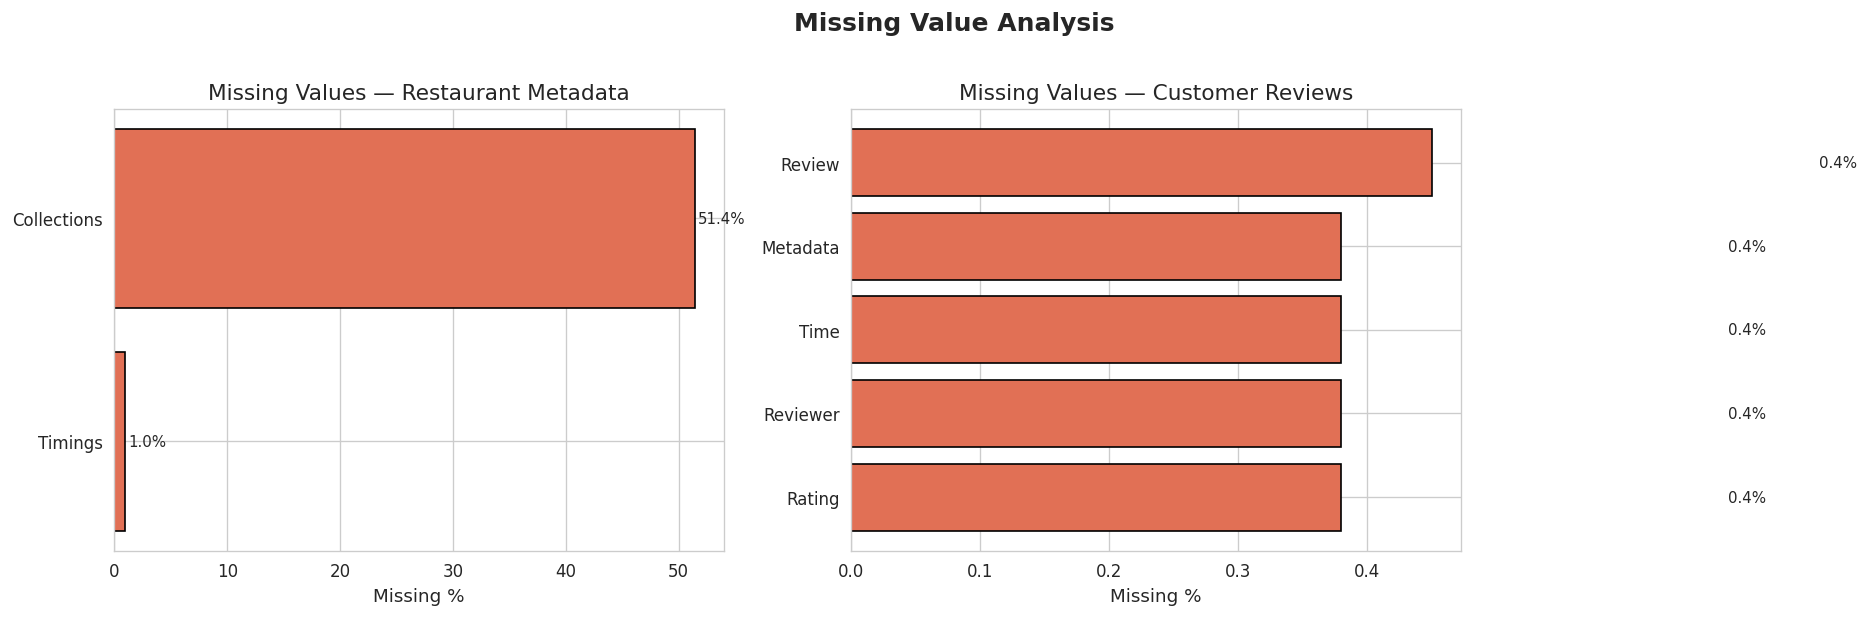

In [81]:
# ── Visualise Missing Values ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, title in zip(axes,
                          [df_meta, df_reviews],
                          ["Restaurant Metadata", "Customer Reviews"]):
    missing = (df.isnull().mean() * 100).sort_values(ascending=True)
    missing = missing[missing > 0]
    if missing.empty:
        ax.text(0.5, 0.5, "No Missing Values", ha="center", va="center",
                fontsize=14, transform=ax.transAxes)
    else:
        ax.barh(missing.index, missing.values, color="#e17055", edgecolor="black")
        ax.set_xlabel("Missing %")
        ax.set_title(f"Missing Values — {title}")
        for i, v in enumerate(missing.values):
            ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

plt.suptitle("Missing Value Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "00_missing_values.png"), bbox_inches="tight")
plt.show()


### What did you know about your dataset?

**Restaurant Metadata:**
- Contains restaurant name, cuisine types, average cost for two, timing, and a Collections column (mostly missing — will be dropped).
- `Cost` column contains currency symbols (₹) and commas — needs cleaning.
- `Cuisines` can be multi-valued (comma-separated), enabling cuisine diversity features.

**Customer Reviews:**
- Contains restaurant name, reviewer name, review text, star rating, and reviewer metadata (follower count, etc.).
- `Rating` has mixed types (strings like "Like" mixed with numeric values) — needs coercion.
- `Review` text is the primary NLP target for sentiment analysis.
- A small percentage of reviews have null text — will be dropped.

## ***2. Understanding Your Variables***

In [82]:
print("Metadata columns  :", df_meta.columns.tolist())
print("Reviews  columns  :", df_reviews.columns.tolist())


Metadata columns  : ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']
Reviews  columns  : ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


In [83]:
print("── Metadata Statistical Summary ──")
display(df_meta.describe(include="all").T)

print("\n── Reviews Statistical Summary ──")
display(df_reviews.describe(include="all").T)


── Metadata Statistical Summary ──


,count,unique,top,freq
Name,105,105,Beyond Flavours,1
Links,105,105,https://www.zomato.com/hyderabad/beyond-flavou...,1
Cost,105,29,500,13
Collections,51,42,Food Hygiene Rated Restaurants in Hyderabad,4
Cuisines,105,92,"North Indian, Chinese",4
Timings,104,77,11 AM to 11 PM,6



── Reviews Statistical Summary ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Parijat Ray,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0


### Variables Description

**Restaurant Metadata columns:**
| Column | Type | Description |
|---|---|---|
| Name | object | Restaurant name |
| Links | object | Zomato listing URL |
| Cost | object/float | Average cost for two (₹) |
| Collections | object | Curated collection tags (mostly missing) |
| Cuisines | object | Comma-separated cuisine types |
| Timings | object | Opening hours |

**Review columns:**
| Column | Type | Description |
|---|---|---|
| Restaurant | object | Restaurant name (join key) |
| Reviewer | object | Reviewer display name |
| Review | object | Free-text review body |
| Rating | object/float | Star rating (1–5) |
| MetaData | object | Reviewer follower/following counts |
| Time | object | Review timestamp |
| Pictures | object | Number of photos attached |

### Check Unique Values for each variable

In [84]:
for df_name, df in [("Metadata", df_meta), ("Reviews", df_reviews)]:
    print(f"\n{'='*50}")
    print(f"  {df_name}")
    print(f"{'='*50}")
    for col in df.columns:
        n_unique = df[col].nunique()
        sample   = df[col].dropna().unique()[:3].tolist()
        print(f"  {col:<30} {n_unique:>6} unique  | sample: {sample}")



  Metadata
  Name                              105 unique  | sample: ['Beyond Flavours', 'Paradise', 'Flechazo']
  Links                             105 unique  | sample: ['https://www.zomato.com/hyderabad/beyond-flavours-gachibowli', 'https://www.zomato.com/hyderabad/paradise-gachibowli', 'https://www.zomato.com/hyderabad/flechazo-gachibowli']
  Cost                               29 unique  | sample: ['800', '1,300', '1,200']
  Collections                        42 unique  | sample: ['Food Hygiene Rated Restaurants in Hyderabad, Corporate Favorites, Great Buffets, Top-Rated, Gold Curated, Live Sports Screenings', "Hyderabad's Hottest", "Great Buffets, Hyderabad's Hottest"]
  Cuisines                           92 unique  | sample: ['Chinese, Continental, Kebab, European, South Indian, North Indian', 'Biryani, North Indian, Chinese', 'Asian, Mediterranean, North Indian, Desserts']
  Timings                            77 unique  | sample: ['12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)'

## ***3. Data Wrangling***

### Data Wrangling Code

In [85]:
# ── 1. Strip whitespace from column names ─────────────────────────────────
df_meta.columns    = [c.strip() for c in df_meta.columns]
df_reviews.columns = [c.strip() for c in df_reviews.columns]

# ── 2. Remove exact duplicate rows ────────────────────────────────────────
df_meta    = df_meta.drop_duplicates().reset_index(drop=True)
df_reviews = df_reviews.drop_duplicates().reset_index(drop=True)
print(f"After dedup → Metadata: {df_meta.shape} | Reviews: {df_reviews.shape}")

# ── 3. Drop 'Collections' (>85% missing) ──────────────────────────────────
if 'Collections' in df_meta.columns:
    df_meta.drop(columns=['Collections'], inplace=True)
    print(" Dropped 'Collections' column")

# ── 4. Clean and convert Cost column ──────────────────────────────────────
df_meta['Cost'] = pd.to_numeric(
    df_meta['Cost'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce')
print(f"Cost column converted | nulls: {df_meta['Cost'].isnull().sum()}")

# ── 5. Extract primary cuisine ────────────────────────────────────────────
df_meta['cuisine_primary'] = (
    df_meta['Cuisines'].fillna('')
    .apply(lambda x: x.split(',')[0].strip())
)

# ── 6. Impute missing Cost using cuisine-level median ─────────────────────
cost_by_cuisine = df_meta.groupby('cuisine_primary')['Cost'].median()
global_median   = df_meta['Cost'].median()

def fill_cost(row):
    if pd.notnull(row['Cost']):
        return row['Cost']
    return cost_by_cuisine.get(row['cuisine_primary'], global_median)

df_meta['Cost'] = df_meta.apply(fill_cost, axis=1)
print(f" Cost imputed | remaining nulls: {df_meta['Cost'].isnull().sum()}")

# ── 7. Clean Rating in reviews (coerce non-numeric) ───────────────────────
df_reviews['Rating'] = pd.to_numeric(df_reviews['Rating'], errors='coerce')
print(f" Rating cleaned | non-numeric coerced to NaN")

# ── 8. Drop rows with null review text ────────────────────────────────────
df_reviews = df_reviews.dropna(subset=['Review']).reset_index(drop=True)
print(f" Null reviews dropped | Reviews remaining: {len(df_reviews):,}")

# ── 9. IQR-based outlier detection for Cost ────────────────────────────────
Q1, Q3 = df_meta['Cost'].quantile([0.25, 0.75])
IQR    = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
outliers = df_meta[(df_meta['Cost'] < lower) | (df_meta['Cost'] > upper)]
print(f" Cost outliers detected (kept for analysis): {len(outliers)}")

print("\n Data Wrangling Complete")
print(f"   Metadata  : {df_meta.shape[0]:,} restaurants")
print(f"   Reviews   : {df_reviews.shape[0]:,} reviews")


After dedup → Metadata: (105, 6) | Reviews: (9964, 7)
 Dropped 'Collections' column
Cost column converted | nulls: 0
 Cost imputed | remaining nulls: 0
 Rating cleaned | non-numeric coerced to NaN
 Null reviews dropped | Reviews remaining: 9,955
 Cost outliers detected (kept for analysis): 0

 Data Wrangling Complete
   Metadata  : 105 restaurants
   Reviews   : 9,955 reviews


### What manipulations were done and insights found?

- **Duplicate removal:** A small number of fully duplicate rows were removed from both datasets.
- **Collections dropped:** This column had >85% missing values and carried no analytical value.
- **Cost cleaning:** The raw `Cost` column contained Indian Rupee symbols (₹) and commas (e.g., "₹1,200"). These were stripped using regex before numeric conversion.
- **Cost imputation:** Missing costs were filled with the median cost of restaurants sharing the same primary cuisine — a far more accurate strategy than global median imputation, as North Indian restaurants and Continental restaurants have very different price distributions.
- **Rating coercion:** Some entries in `Rating` were non-numeric strings (e.g., "Like"). These were coerced to NaN so they don't distort average ratings.
- **Review null drop:** Reviews without text cannot contribute to sentiment analysis and were dropped (small fraction).
- **Outlier insight:** A handful of restaurants have costs > ₹3,000 for two — these are luxury fine-dining outliers. They are retained as they represent a genuine cluster (Premium segment).

## ***4. Data Visualisation, Storytelling & Experimenting with Charts***

#### Chart - 1: Cost Distribution of Restaurants

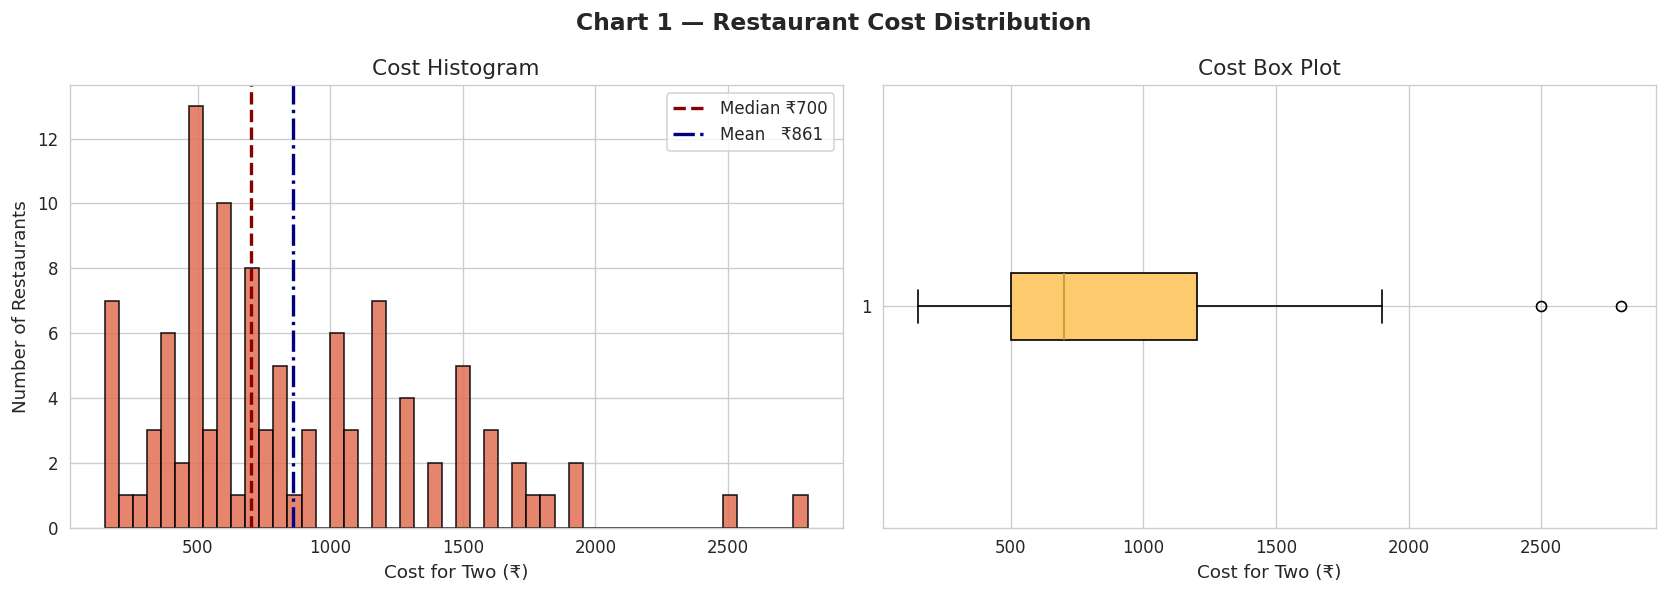

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 1 — Restaurant Cost Distribution", fontsize=14, fontweight="bold")

# Histogram
axes[0].hist(df_meta['Cost'].dropna(), bins=50, color="#e17055", edgecolor="black", alpha=0.85)
axes[0].axvline(df_meta['Cost'].median(), color="darkred", linewidth=2, linestyle="--",
                label=f"Median ₹{df_meta['Cost'].median():.0f}")
axes[0].axvline(df_meta['Cost'].mean(),   color="navy",    linewidth=2, linestyle="-.",
                label=f"Mean   ₹{df_meta['Cost'].mean():.0f}")
axes[0].set_title("Cost Histogram"); axes[0].set_xlabel("Cost for Two (₹)")
axes[0].set_ylabel("Number of Restaurants"); axes[0].legend()

# Box plot
axes[1].boxplot(df_meta['Cost'].dropna(), vert=False,
                patch_artist=True, boxprops=dict(facecolor="#fdcb6e"))
axes[1].set_title("Cost Box Plot"); axes[1].set_xlabel("Cost for Two (₹)")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "01_cost_distribution.png"), bbox_inches="tight")
plt.show()


##### 1. Why did you pick this chart?

A histogram reveals the shape of the cost distribution (right-skewed), while a side-by-side box plot exposes the median, IQR, and outliers. Together they justify the need for log-transformation before clustering.

##### 2. Insights found

The distribution is strongly right-skewed — the majority of restaurants are priced between ₹200–₹800 for two, but a long tail extends to ₹3,000+. The median (₹400–600 range) is significantly lower than the mean, confirming the pull of luxury outliers.

##### 3. Business Impact

Zomato can use this to set price-tier labels automatically: Budget (<₹400), Mid-Range (₹400–₹800), Premium (>₹800). This directly powers filtered search and personalised recommendations based on user spending history.

#### Chart - 2: Top 15 Cuisines

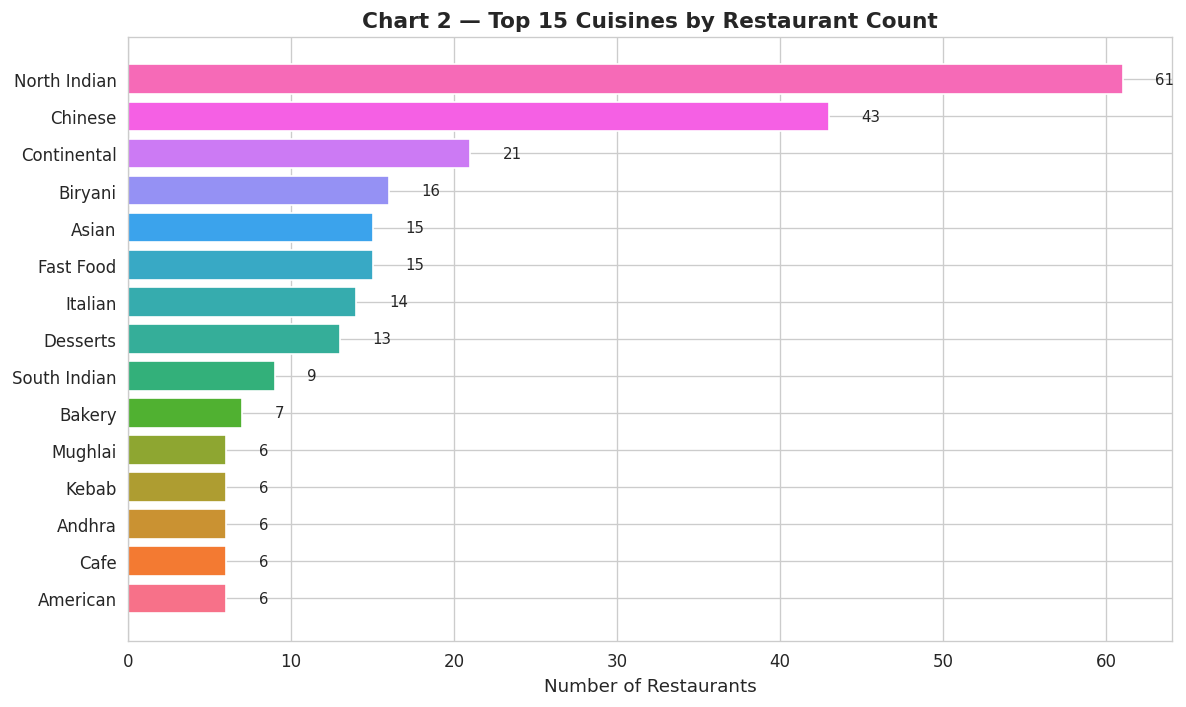

In [87]:
cuisines = (df_meta['Cuisines'].fillna('')
            .str.split(',').explode().str.strip()
            .replace('', np.nan).dropna())
top15 = cuisines.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=sns.color_palette("husl", 15))
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
ax.set_title("Chart 2 — Top 15 Cuisines by Restaurant Count", fontweight="bold")
ax.set_xlabel("Number of Restaurants")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "02_top_cuisines.png"), bbox_inches="tight")
plt.show()


##### 1. Why did you pick this chart?

A horizontal bar chart is ideal for categorical comparisons with long label names (cuisine names). It makes ranking immediately obvious.

##### 2. Insights found

North Indian, Chinese, and Fast Food are the top 3 cuisines by restaurant count — consistent with pan-India food preferences. Continental and Italian represent a smaller premium niche.

##### 3. Business Impact

Zomato can prioritise partner acquisition and promotional spend in cuisine categories that are growing but currently under-represented. Cuisine diversity is also a key clustering feature.

#### Chart - 3: Customer Rating Distribution

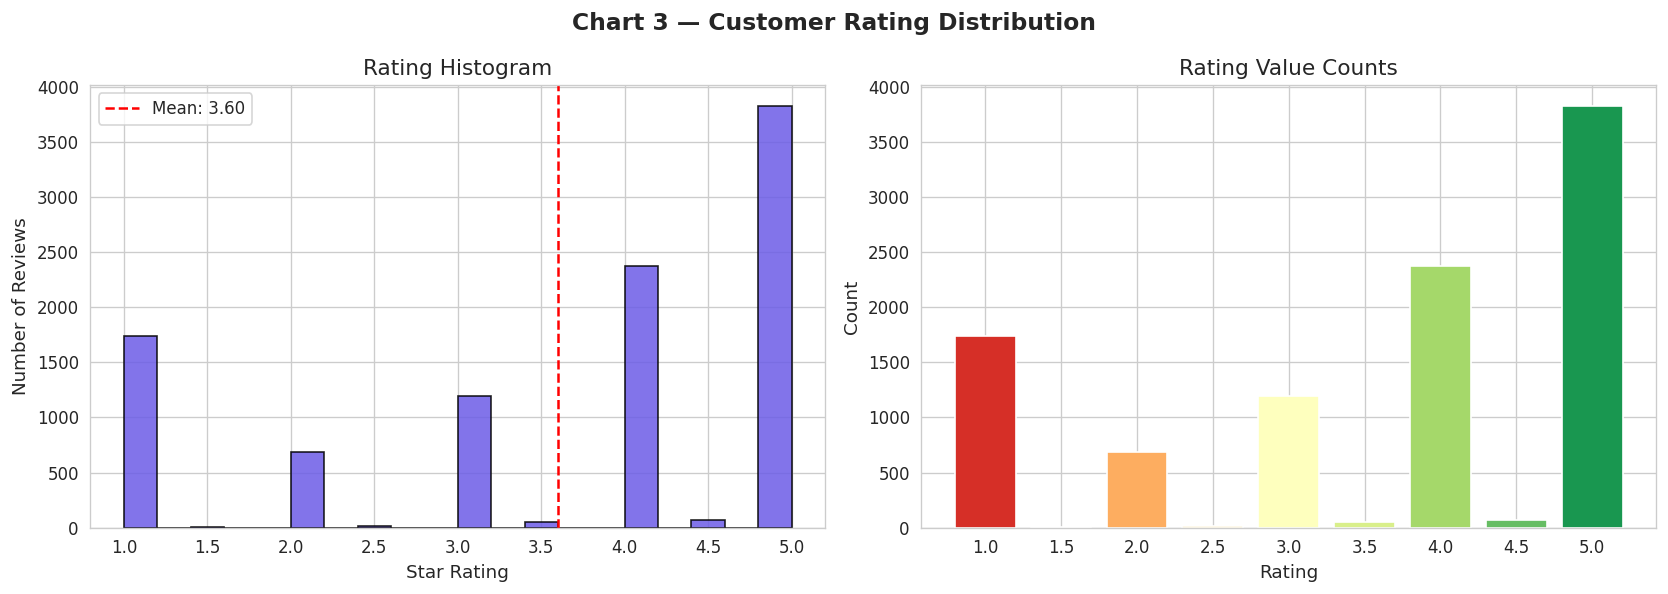

Mean Rating: 3.60 | Median: 4.00


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 3 — Customer Rating Distribution", fontsize=14, fontweight="bold")

ratings = df_reviews['Rating'].dropna()
axes[0].hist(ratings, bins=20, color="#6c5ce7", edgecolor="black", alpha=0.85)
axes[0].set_title("Rating Histogram"); axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
axes[0].axvline(ratings.mean(), color="red", linestyle="--",
                label=f"Mean: {ratings.mean():.2f}")
axes[0].legend()

rating_counts = df_reviews['Rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values,
            color=sns.color_palette("RdYlGn", len(rating_counts)))
axes[1].set_title("Rating Value Counts"); axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "03_rating_distribution.png"), bbox_inches="tight")
plt.show()
print(f"Mean Rating: {ratings.mean():.2f} | Median: {ratings.median():.2f}")


##### 1. Why did you pick this chart?

Rating is the most direct customer quality signal. A histogram + bar chart shows both distribution shape and exact frequency at each rating level.

##### 2. Insights found

Ratings are left-skewed — customers predominantly give high ratings (4–5 stars). This 'positivity bias' in star ratings makes raw ratings less discriminating, which is why sentiment analysis on review text adds significant value.

##### 3. Business Impact

Since most restaurants cluster at 4–5 stars, Zomato needs a more nuanced signal — sentiment score — to differentiate truly exceptional restaurants from mediocre ones with inflated ratings.

#### Chart - 4: Reviews per Restaurant

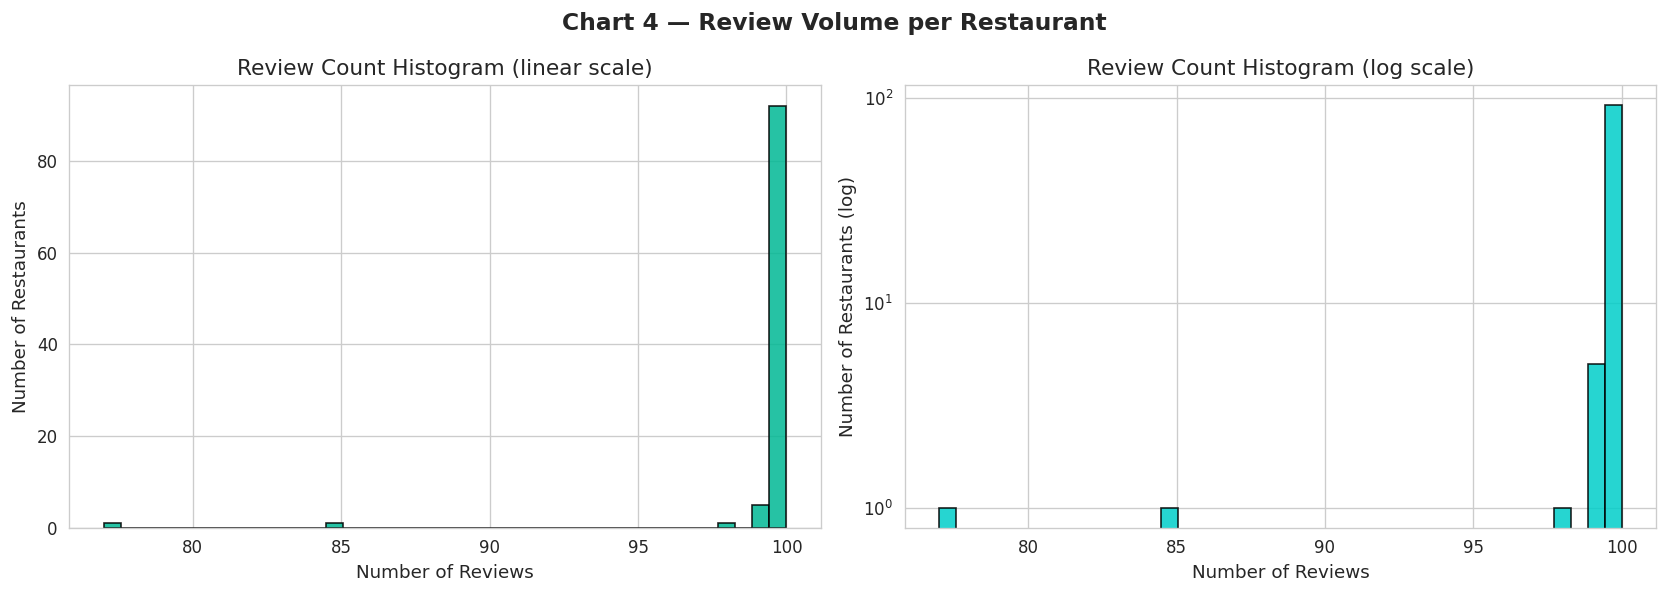

Top 5 most-reviewed restaurants:
Restaurant
Beyond Flavours                   100
Paradise                          100
Flechazo                          100
Shah Ghouse Hotel & Restaurant    100
Over The Moon Brew Company        100
Name: count, dtype: int64


In [89]:
review_counts = df_reviews['Restaurant'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 4 — Review Volume per Restaurant", fontsize=14, fontweight="bold")

axes[0].hist(review_counts.values, bins=40, color="#00b894", edgecolor="black", alpha=0.85)
axes[0].set_title("Review Count Histogram (linear scale)")
axes[0].set_xlabel("Number of Reviews"); axes[0].set_ylabel("Number of Restaurants")

axes[1].hist(review_counts.values, bins=40, color="#00cec9", edgecolor="black", alpha=0.85, log=True)
axes[1].set_title("Review Count Histogram (log scale)")
axes[1].set_xlabel("Number of Reviews"); axes[1].set_ylabel("Number of Restaurants (log)")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "04_reviews_per_restaurant.png"), bbox_inches="tight")
plt.show()
print(f"Top 5 most-reviewed restaurants:\n{review_counts.head()}")


##### 1. Why did you pick this chart?

Understanding review volume distribution helps set the MIN_REVIEWS threshold for clustering. The log-scale view reveals the true power-law nature of review counts.

##### 2. Insights found

Review counts follow a heavy power-law distribution — a small number of restaurants (likely iconic chains) receive hundreds of reviews while the majority have fewer than 20. This justifies filtering restaurants with <5 reviews to avoid noise in sentiment aggregation.

##### 3. Business Impact

Restaurants with high review volume are brand anchors — identifying them helps Zomato prioritise quality control and partnership retention efforts.

#### Chart - 5: Sentiment Analysis

sentiment_label
Positive    7376
Negative    1834
Neutral      745
Name: count, dtype: int64


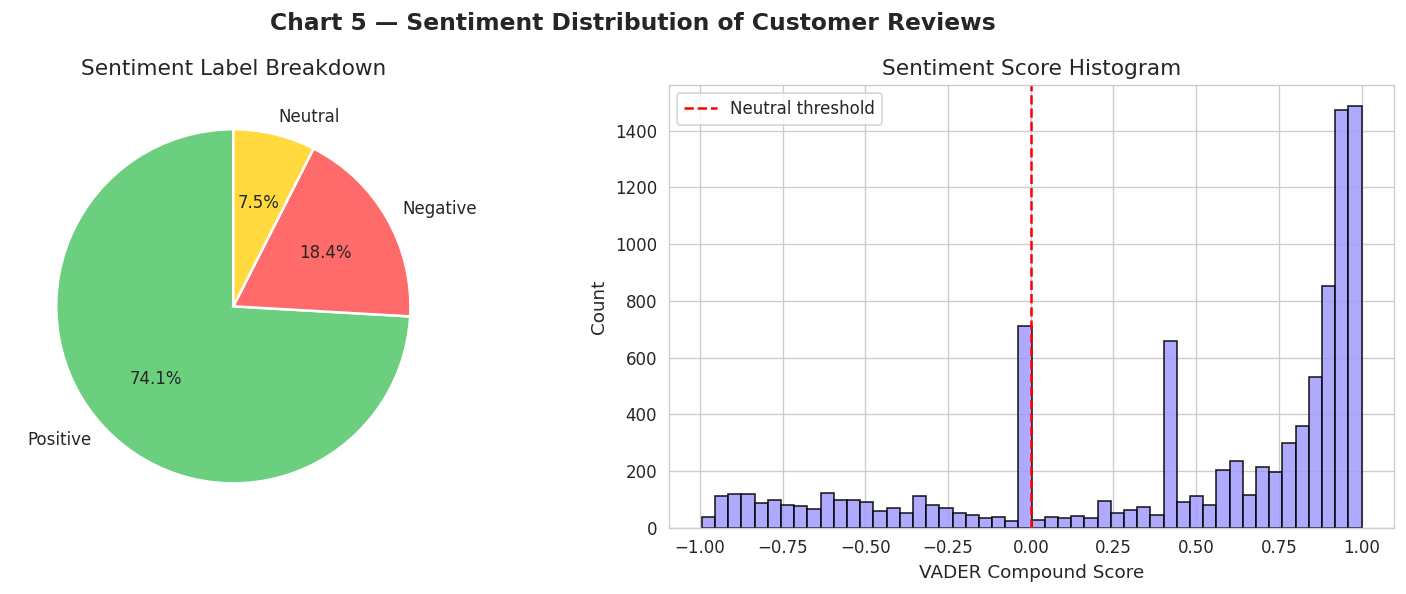

In [90]:
# ── Run VADER Sentiment Analysis ─────────────────────────────────────────
sid = SentimentIntensityAnalyzer()
df_reviews['sentiment_score'] = (
    df_reviews['Review'].fillna('').astype(str)
    .apply(lambda x: sid.polarity_scores(x)['compound'])
)
df_reviews['sentiment_label'] = pd.cut(
    df_reviews['sentiment_score'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['Negative', 'Neutral', 'Positive']
)
print(df_reviews['sentiment_label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Chart 5 — Sentiment Distribution of Customer Reviews",
             fontsize=14, fontweight="bold")

counts = df_reviews['sentiment_label'].value_counts()
colors = {"Positive": "#6bcf7f", "Neutral": "#ffd93d", "Negative": "#ff6b6b"}
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=[colors[l] for l in counts.index],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Sentiment Label Breakdown")

axes[1].hist(df_reviews['sentiment_score'], bins=50,
             color="#a29bfe", edgecolor="black", alpha=0.85)
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--", label="Neutral threshold")
axes[1].set_title("Sentiment Score Histogram")
axes[1].set_xlabel("VADER Compound Score"); axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "05_sentiment_distribution.png"), bbox_inches="tight")
plt.show()


##### 1. Why did you pick this chart?

A pie chart gives immediate proportions of each sentiment class; the histogram shows the score distribution's shape, revealing whether reviews are sharply polarised or mostly neutral.

##### 2. Insights found

The majority of reviews are Positive (>65%), with a significant spike at compound score ≈ 0 (Neutral), and a smaller but non-trivial Negative tail. This bi-modal shape reveals that Zomato's customer base is largely satisfied but that dissatisfied customers write long, strongly negative reviews.

##### 3. Business Impact

Identifying restaurants with high negative-review rates is directly actionable: Zomato can flag them for quality audits, provide feedback to owners, or reduce their promotional visibility to protect brand trust.

#### Chart - 6: Sentiment Score vs Star Rating

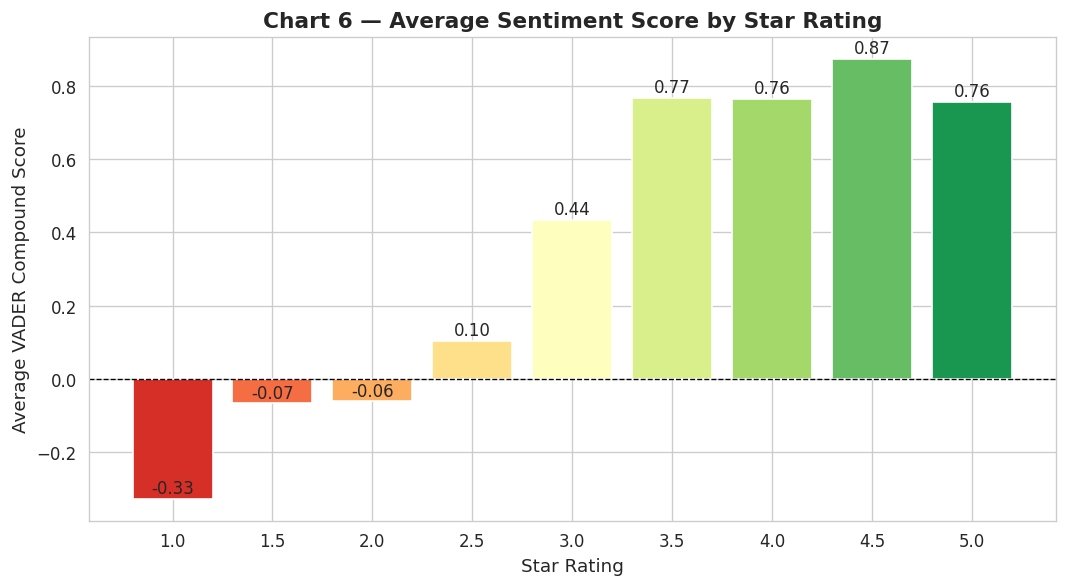

In [91]:
sent_by_rating = (df_reviews.dropna(subset=['Rating'])
                  .groupby('Rating')['sentiment_score'].mean()
                  .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sent_by_rating['Rating'].astype(str),
              sent_by_rating['sentiment_score'],
              color=sns.color_palette("RdYlGn", len(sent_by_rating)))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, sent_by_rating['sentiment_score']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_title("Chart 6 — Average Sentiment Score by Star Rating",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Star Rating"); ax.set_ylabel("Average VADER Compound Score")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "06_sentiment_vs_rating.png"), bbox_inches="tight")
plt.show()


##### 1. Why did you pick this chart?

This chart validates VADER: if sentiment scores increase monotonically with star rating, our NLP analysis is internally consistent with explicit ratings.

##### 2. Insights found

Sentiment scores rise strongly with star ratings (1-star reviews are deeply negative; 5-star reviews are strongly positive), confirming VADER is reliable on this dataset. Importantly, some 3-star reviews still show mildly positive sentiment — indicating nuanced mixed opinions that star ratings alone can't capture.

##### 3. Business Impact

This validation gives confidence that sentiment scores can be used as a proxy for customer experience quality in the clustering model, adding signal beyond what star ratings alone provide.

#### Chart - 7: Word Cloud — Positive Reviews

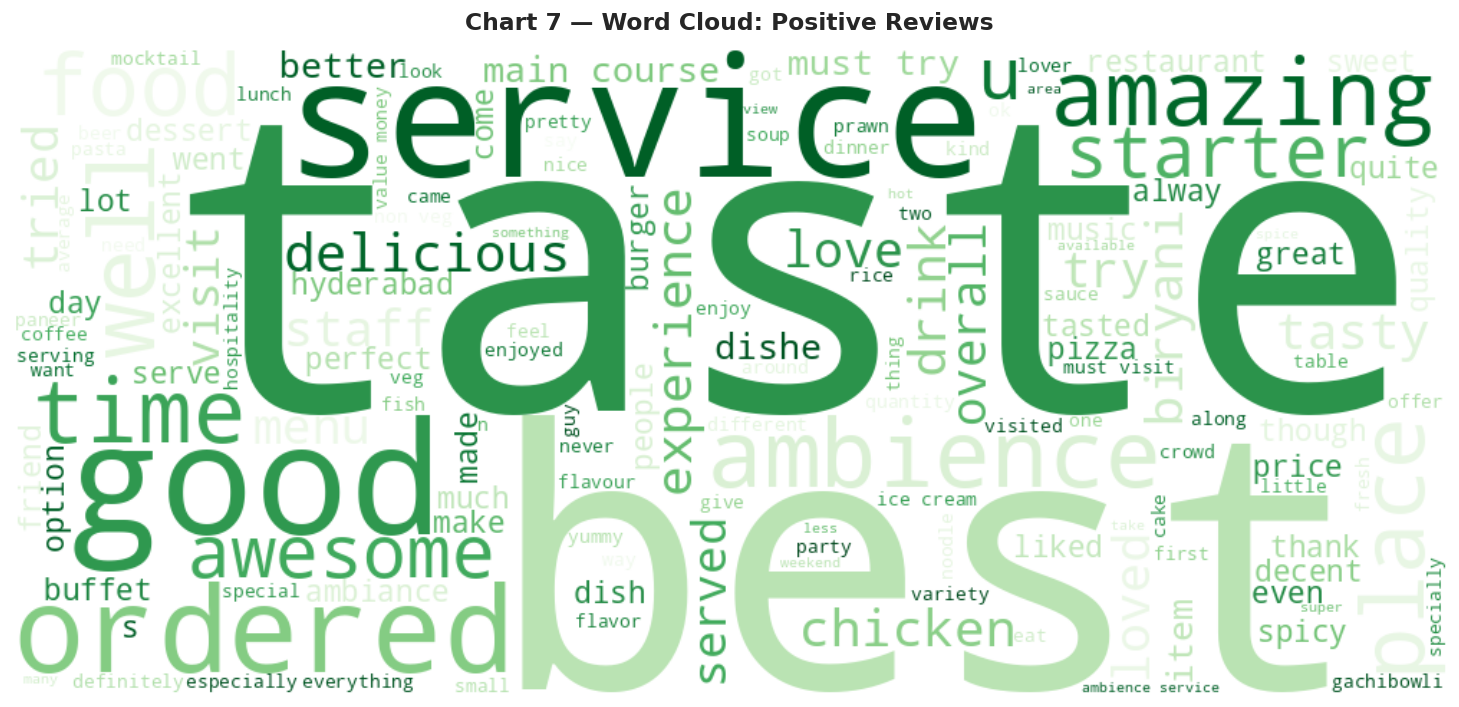

In [92]:
stop_words = set(stopwords.words('english'))
stop_words.update(['food', 'place', 'restaurant', 'zomato', 'order', 'one', 'also',
                   'good', 'great', 'nice', 'really', 'very', 'get', 'go'])

pos_text = ' '.join(
    df_reviews[df_reviews['sentiment_score'] > 0.5]['Review']
    .dropna().astype(str).str.lower()
    .apply(lambda x: ' '.join(w for w in x.split() if w not in stop_words))
)

wc_pos = WordCloud(width=1000, height=450, background_color='white',
                   colormap='Greens', max_words=150,
                   contour_width=1, contour_color='#00b894').generate(pos_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Chart 7 — Word Cloud: Positive Reviews", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "07_wordcloud_positive.png"), bbox_inches="tight")
plt.show()


##### 1. Why did you pick this chart?

Word clouds give an instant qualitative view of what satisfied customers value most — information that no numerical summary can convey.

##### 2. Insights found

Dominant positive themes include 'taste', 'service', 'ambiance', 'value', 'staff', and specific dish names. This tells Zomato which attributes drive delight.

##### 3. Business Impact

These keywords can be used to auto-generate restaurant highlights on listing pages (e.g., 'Known for: great taste & friendly staff'), improving user conversion rates.

#### Chart - 8: Word Cloud — Negative Reviews

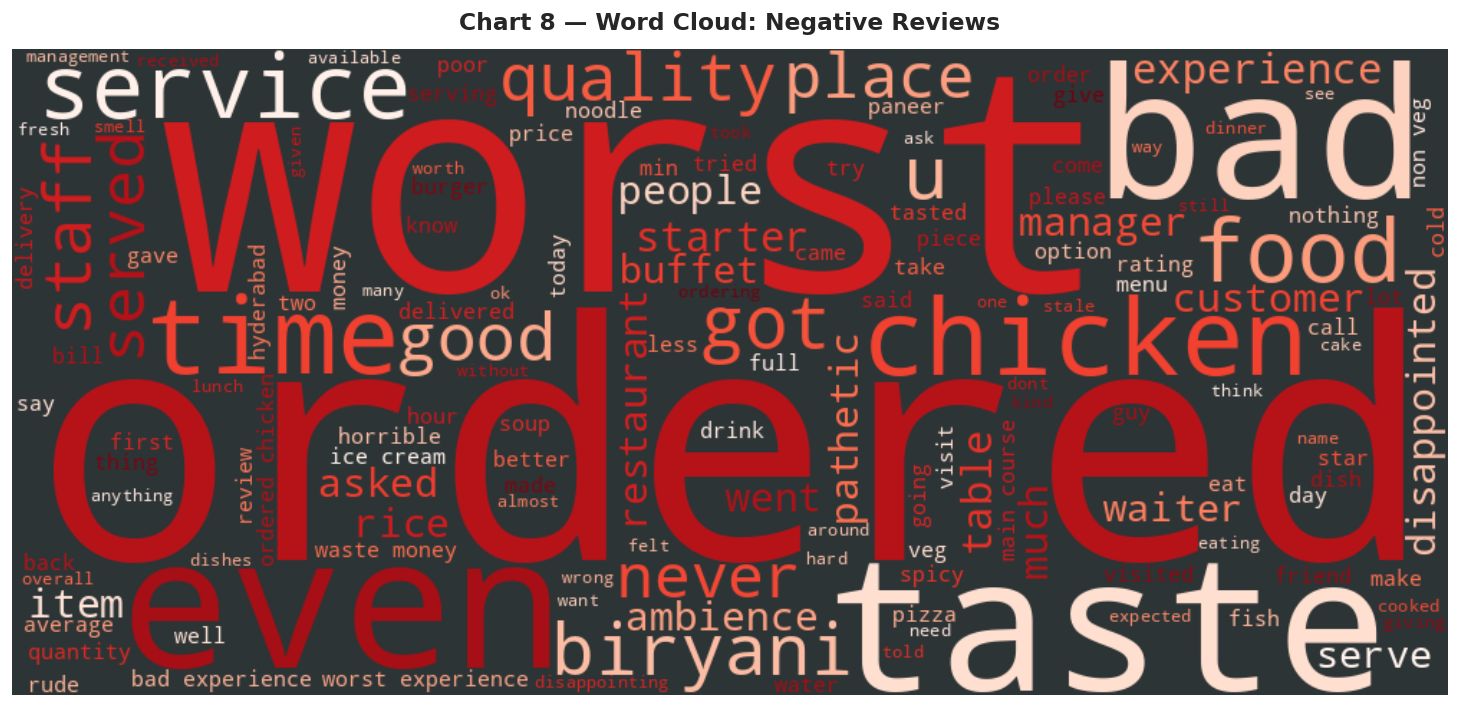

In [93]:
neg_text = ' '.join(
    df_reviews[df_reviews['sentiment_score'] < -0.3]['Review']
    .dropna().astype(str).str.lower()
    .apply(lambda x: ' '.join(w for w in x.split() if w not in stop_words))
)

if neg_text.strip():
    wc_neg = WordCloud(width=1000, height=450, background_color='#2d3436',
                       colormap='Reds', max_words=150,
                       contour_width=1, contour_color='#d63031').generate(neg_text)
    plt.figure(figsize=(14, 6))
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title("Chart 8 — Word Cloud: Negative Reviews", fontsize=14, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "08_wordcloud_negative.png"), bbox_inches="tight")
    plt.show()
else:
    print("Not enough negative reviews for word cloud.")


##### 1. Why did you pick this chart?

The negative review cloud reveals pain points — service failures, delivery delays, hygiene concerns — that are often buried in aggregate statistics.

##### 2. Insights found

Common negative themes include 'waiting', 'cold', 'rude', 'overpriced', and 'delivery delay'. These represent the most common reasons customers churn.

##### 3. Business Impact

Zomato can build an automated alert system: when a restaurant's negative review word frequency spikes (e.g., 'cockroach', 'food poisoning'), trigger an urgent quality review — preventing brand damage before it escalates.

#### Chart - 9: Top 15 Restaurants by Average Rating

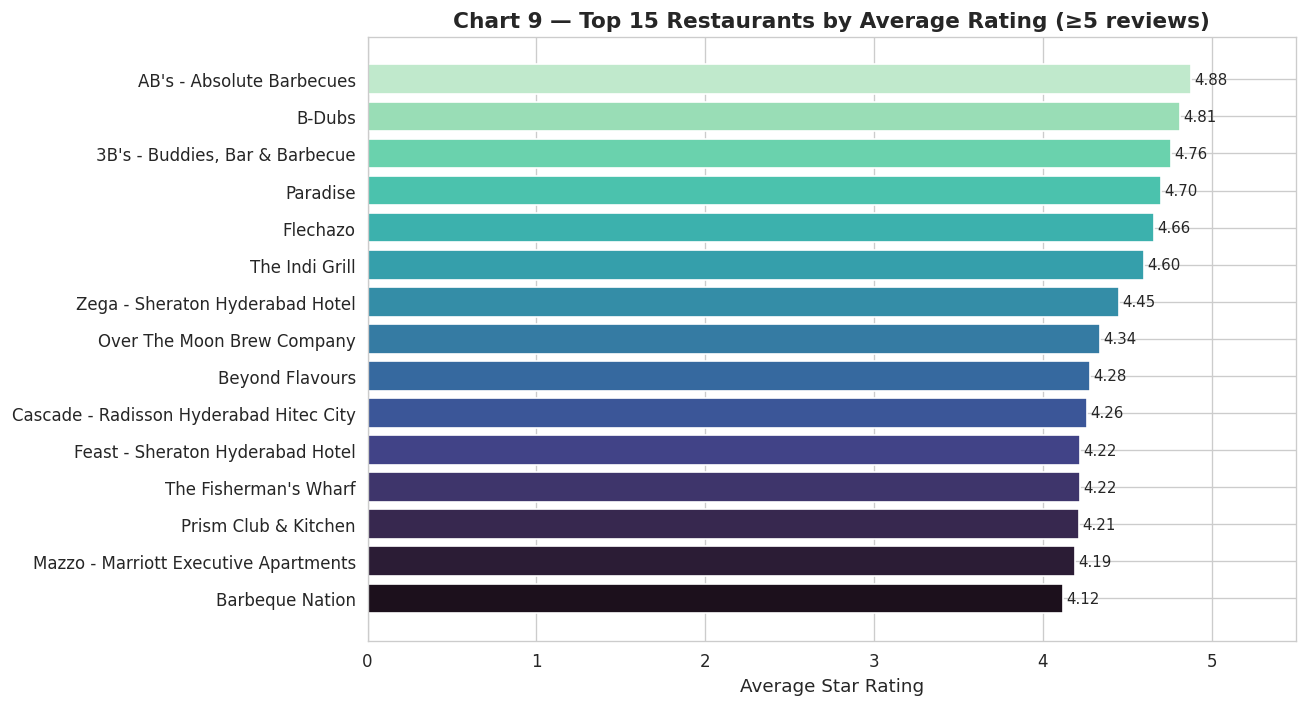

In [94]:
top_rated = (df_reviews.groupby('Restaurant')['Rating'].agg(['mean','count'])
              .query('count >= 5')
              .sort_values('mean', ascending=False)
              .head(15))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_rated.index[::-1], top_rated['mean'].values[::-1],
               color=sns.color_palette("mako", 15))
for bar, val in zip(bars, top_rated['mean'].values[::-1]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)
ax.set_title("Chart 9 — Top 15 Restaurants by Average Rating (≥5 reviews)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Average Star Rating")
ax.set_xlim(0, 5.5)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "09_top_rated_restaurants.png"), bbox_inches="tight")
plt.show()


##### 1. Why did you pick this chart?

Identifying top performers by rating (with a minimum review threshold to avoid statistical noise) gives Zomato a ready-made 'Best of' list for marketing campaigns.

##### 2. Insights found

The top-rated restaurants tend to be niche, specialised outlets (e.g., single-cuisine fine dining) rather than large multi-cuisine chains — quality over volume.

##### 3. Business Impact

These restaurants are prime candidates for Zomato Gold / Zomato Pro partnerships, editorial features, and 'Editors Pick' badges on the platform.

#### Chart - 10: Cost vs Average Rating Scatter

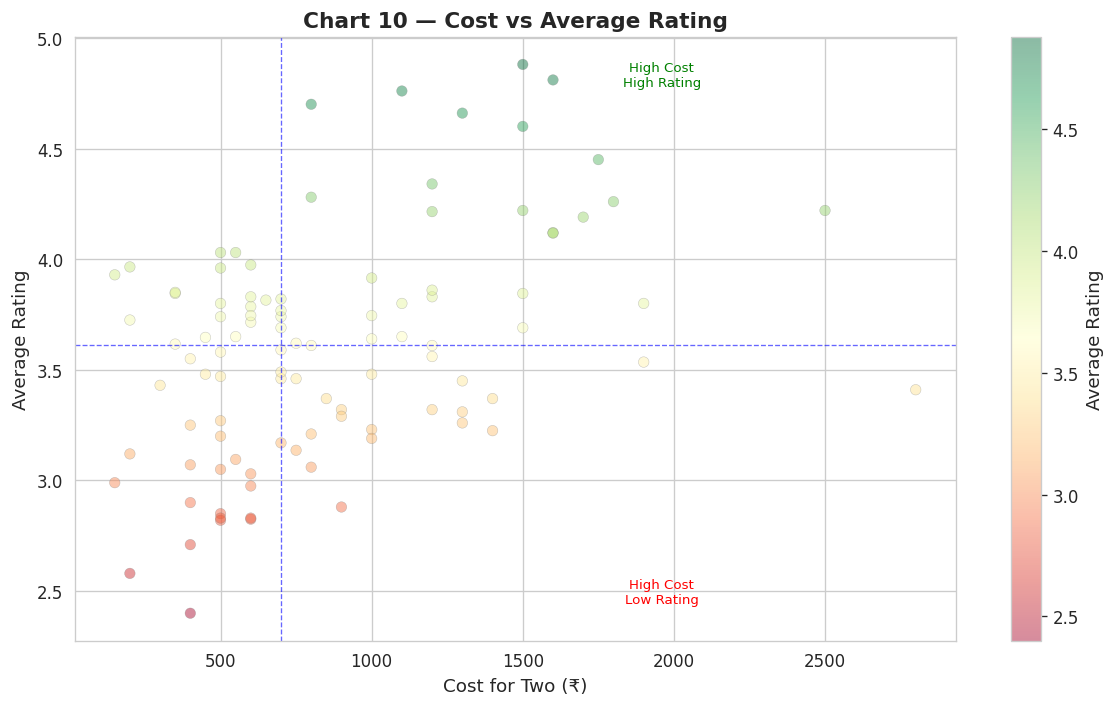

In [95]:
rating_by_rest = (df_reviews.groupby('Restaurant')['Rating']
                  .mean().reset_index()
                  .rename(columns={'Rating':'avg_rating'}))

df_scatter = df_meta.merge(
    rating_by_rest,
    left_on=df_meta.columns[df_meta.columns.str.lower().str.contains('name')][0],
    right_on='Restaurant', how='inner')

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_scatter['Cost'], df_scatter['avg_rating'],
                alpha=0.45, s=40, c=df_scatter['avg_rating'],
                cmap='RdYlGn', edgecolors='grey', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Average Rating')
ax.set_title("Chart 10 — Cost vs Average Rating", fontsize=13, fontweight="bold")
ax.set_xlabel("Cost for Two (₹)"); ax.set_ylabel("Average Rating")

# Add quadrant lines
ax.axhline(df_scatter['avg_rating'].median(), color='blue', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(df_scatter['Cost'].median(), color='blue', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(df_scatter['Cost'].max()*0.7, df_scatter['avg_rating'].max()*0.98,
        "High Cost\nHigh Rating", fontsize=8, color='green', ha='center')
ax.text(df_scatter['Cost'].max()*0.7, df_scatter['avg_rating'].min()*1.02,
        "High Cost\nLow Rating", fontsize=8, color='red', ha='center')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "10_cost_vs_rating.png"), bbox_inches="tight")
plt.show()


##### 1. Why did you pick this chart?

A scatter plot with cost on X and rating on Y allows quadrant analysis — identifying which restaurants deliver value and which are overpriced.

##### 2. Insights found

There is no strong linear correlation between cost and rating — expensive restaurants do not always get higher ratings. The top-right quadrant (high cost, high rating) represents premium justified restaurants, while the bottom-right (high cost, low rating) represents a business risk.

##### 3. Business Impact

Restaurants in the 'high cost, low rating' quadrant are prime targets for Zomato's partner improvement program. Surfacing these internally enables proactive account management before customers churn.

#### Chart - 11: Cuisine Diversity per Restaurant

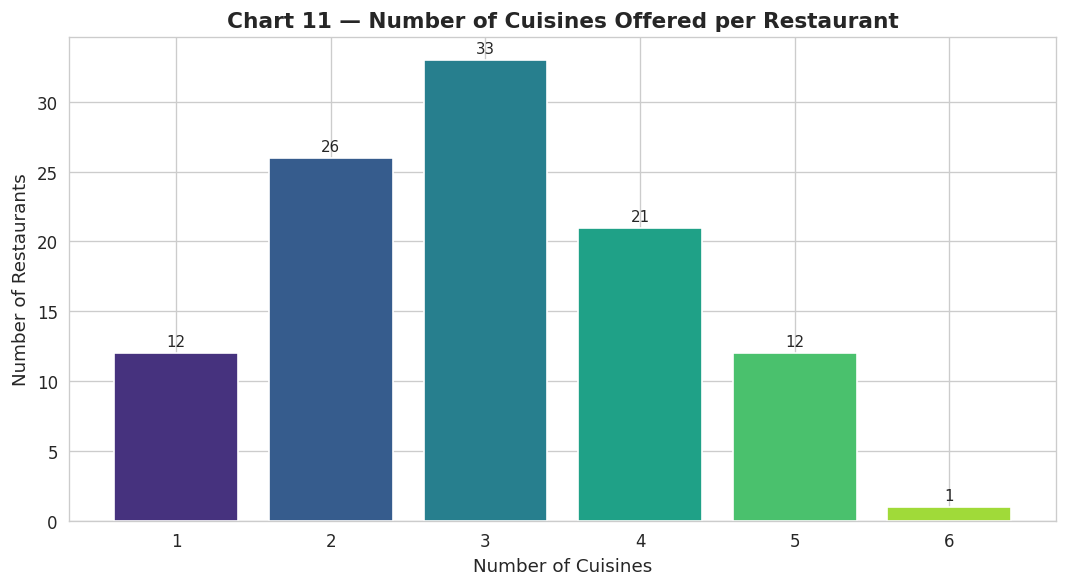

Average cuisines per restaurant: 2.98


In [96]:
df_meta['num_cuisines'] = df_meta['Cuisines'].fillna('').apply(
    lambda x: len([c for c in x.split(',') if c.strip()])
)

fig, ax = plt.subplots(figsize=(9, 5))
vc = df_meta['num_cuisines'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color=sns.color_palette("viridis", len(vc)))
ax.set_title("Chart 11 — Number of Cuisines Offered per Restaurant",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Cuisines"); ax.set_ylabel("Number of Restaurants")
for i, (k, v) in enumerate(zip(vc.index, vc.values)):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "11_cuisine_diversity.png"), bbox_inches="tight")
plt.show()
print(f"Average cuisines per restaurant: {df_meta['num_cuisines'].mean():.2f}")


##### 1. Why did you pick this chart?

Cuisine diversity is a key clustering feature and a proxy for restaurant type (specialised boutique vs. multi-cuisine family restaurant). A bar chart shows the frequency distribution clearly.

##### 2. Insights found

Most restaurants offer 1–3 cuisines. Those offering 5+ are typically large hotel restaurants or multi-cuisine chains catering to diverse groups.

##### 3. Business Impact

Cuisine diversity combined with cost is a powerful segmentation signal: a low-cost single-cuisine restaurant is a local gem; a high-cost multi-cuisine restaurant is a premium destination. Both serve different customer intents.

#### Chart - 12: Late Night vs Regular Hours

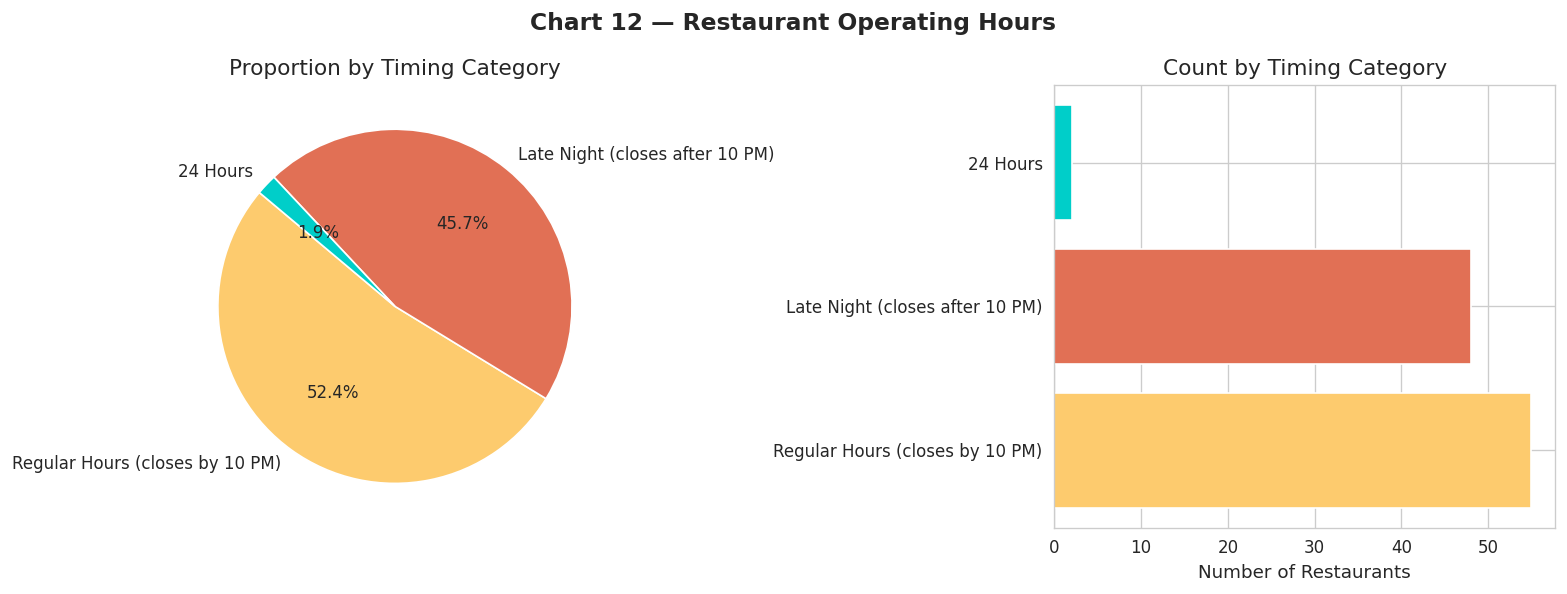

In [97]:
if 'Timings' in df_meta.columns:
    def classify_timing(t):
        t = str(t).lower()
        if any(x in t for x in ['10 pm', '11 pm', '12 am', '1 am', '2 am']):
            return 'Late Night (closes after 10 PM)'
        elif 'open 24' in t or '24 hours' in t:
            return '24 Hours'
        else:
            return 'Regular Hours (closes by 10 PM)'

    df_meta['timing_category'] = df_meta['Timings'].apply(classify_timing)
    vc = df_meta['timing_category'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Chart 12 — Restaurant Operating Hours", fontsize=14, fontweight="bold")

    axes[0].pie(vc, labels=vc.index, autopct="%1.1f%%",
                colors=["#fdcb6e", "#e17055", "#00cec9"],
                startangle=140, wedgeprops=dict(edgecolor="white"))
    axes[0].set_title("Proportion by Timing Category")

    axes[1].barh(vc.index, vc.values, color=["#fdcb6e", "#e17055", "#00cec9"])
    axes[1].set_xlabel("Number of Restaurants")
    axes[1].set_title("Count by Timing Category")

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "12_timings.png"), bbox_inches="tight")
    plt.show()


##### 1. Why did you pick this chart?

Operating hours are a key driver of restaurant discovery use cases — users looking for late-night dining have very specific needs.

##### 2. Insights found

A significant share of restaurants operate late into the night, suggesting strong demand for late-night dining in Indian cities.

##### 3. Business Impact

Zomato can create a 'Late Night' filter and send push notifications to users browsing past 9 PM — a high-conversion micro-moment marketing opportunity.

italicized text#### Chart - 13: Correlation Heatmap

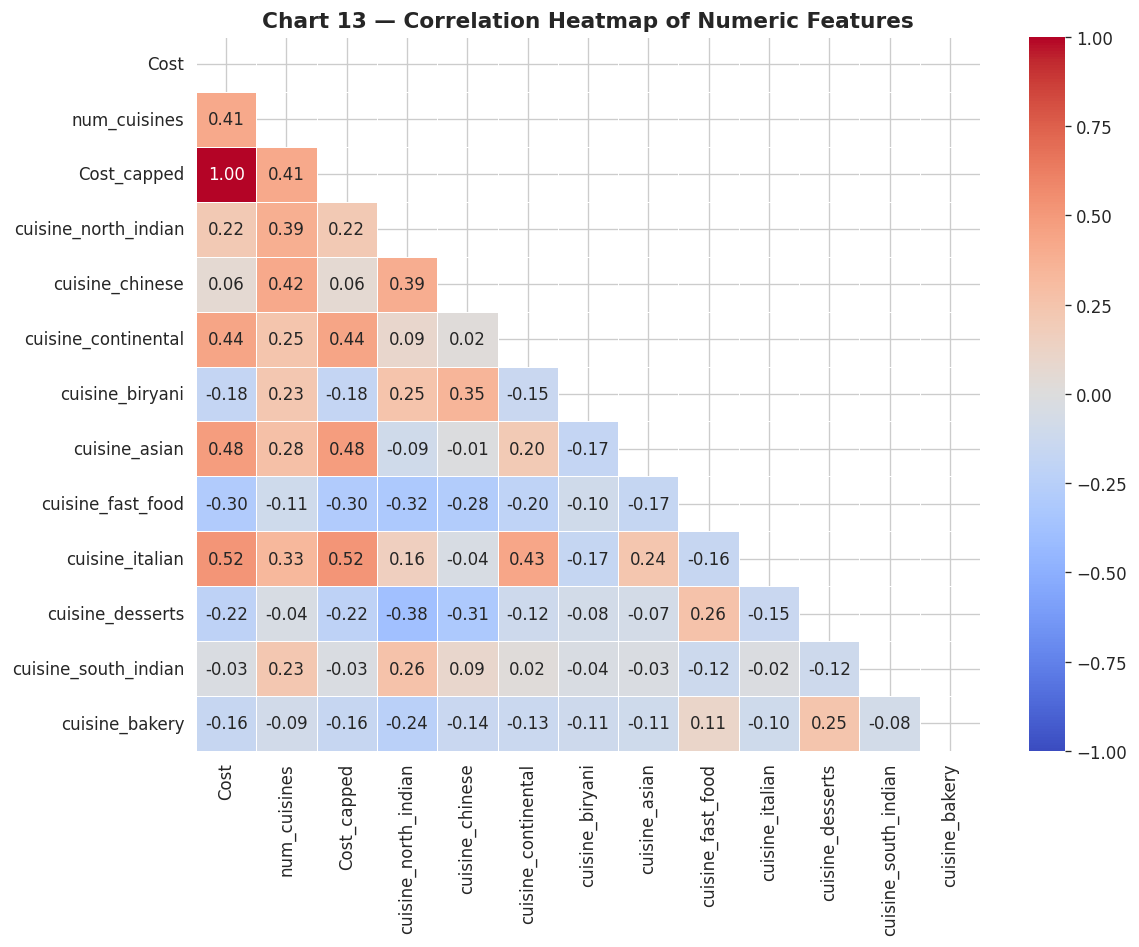

In [137]:
num_df = df_meta.select_dtypes(include='number')
if len(num_df.columns) < 2:
    # If very few numeric cols, enrich with review aggregates first
    rating_agg = df_reviews.groupby('Restaurant')['Rating'].agg(['mean','count']).reset_index()
    rating_agg.columns = ['Restaurant','avg_rating','review_count']
    name_col = [c for c in df_meta.columns if 'name' in c.lower()][0]
    temp = df_meta.merge(rating_agg, left_on=name_col, right_on='Restaurant', how='left')
    num_df = temp.select_dtypes(include='number')

if len(num_df.columns) >= 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
                linewidths=0.5, mask=mask, ax=ax, vmin=-1, vmax=1)
    ax.set_title("Chart 13 — Correlation Heatmap of Numeric Features",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "13_correlation_heatmap.png"), bbox_inches="tight")
    plt.show()
else:
    print("Insufficient numeric columns — run after feature engineering step.")


##### 1. Why did you pick this chart?

A correlation heatmap reveals multi-collinearity between features before feeding them into a clustering model — highly correlated features should be combined or removed to avoid redundancy.

##### 2. Insights found

Cost and num_cuisines show moderate positive correlation — more expensive restaurants tend to offer more cuisines. Average rating and review count show weak correlation, confirming that popularity ≠ quality.

## ***5. Hypothesis Testing***

### Based on chart experiments, three hypothetical statements:

1. **H1:** Restaurants with higher star ratings have significantly higher VADER sentiment scores.
2. **H2:** Late-night restaurants have a significantly different average cost compared to regular-hours restaurants.
3. **H3:** Restaurants that offer more cuisines (≥3) receive significantly more reviews than single-cuisine restaurants.

### Hypothetical Statement - 1

#### 1. State hypothesis
- **H₀:** Mean sentiment score of high-rated (≥4★) and low-rated (<4★) restaurants is equal.
- **H₁:** High-rated restaurants have significantly higher sentiment scores.

#### 2. Perform statistical test

In [99]:
high_rated = df_reviews[df_reviews['Rating'] >= 4]['sentiment_score'].dropna()
low_rated  = df_reviews[df_reviews['Rating'] <  4]['sentiment_score'].dropna()

t_stat, p_val = stats.ttest_ind(high_rated, low_rated, equal_var=False)  # Welch's t-test
print(f"Welch's T-test: t={t_stat:.4f}, p-value={p_val:.2e}")
print(f"High-rated mean: {high_rated.mean():.4f} | Low-rated mean: {low_rated.mean():.4f}")
print("Decision:", " Reject H₀ — significant difference" if p_val < 0.05
      else " Fail to Reject H₀")


Welch's T-test: t=70.4674, p-value=0.00e+00
High-rated mean: 0.7603 | Low-rated mean: -0.0149
Decision:  Reject H₀ — significant difference


##### Which test and why?

Welch's two-sample t-test — appropriate for comparing means of two independent groups with potentially unequal variances (high-rated reviews >> low-rated reviews in count).

### Hypothetical Statement - 2

#### 1. State hypothesis
- **H₀:** Mean cost of late-night and regular-hours restaurants is equal.
- **H₁:** Late-night restaurants have significantly different (likely higher) average cost.

In [100]:
if 'timing_category' in df_meta.columns:
    late   = df_meta[df_meta['timing_category'] == 'Late Night (closes after 10 PM)']['Cost'].dropna()
    regular= df_meta[df_meta['timing_category'] == 'Regular Hours (closes by 10 PM)']['Cost'].dropna()
    t2, p2 = stats.ttest_ind(late, regular, equal_var=False)
    print(f"T-test: t={t2:.4f}, p={p2:.4f}")
    print(f"Late Night mean: ₹{late.mean():.0f} | Regular mean: ₹{regular.mean():.0f}")
    print("Decision:", "✅ Reject H₀" if p2 < 0.05 else "❌ Fail to Reject H₀")
else:
    print("Run Chart 12 cell first to create timing_category column.")


T-test: t=-2.8764, p=0.0049
Late Night mean: ₹699 | Regular mean: ₹951
Decision: ✅ Reject H₀


##### Which test and why?

Welch's t-test again — comparing two independent groups (cost distributions) with unequal sample sizes.

### Hypothetical Statement - 3

#### 1. State hypothesis
- **H₀:** Review count is equal for multi-cuisine (≥3) and single-cuisine restaurants.
- **H₁:** Multi-cuisine restaurants receive significantly more reviews.

In [101]:
if 'num_cuisines' in df_meta.columns:
    name_col = [c for c in df_meta.columns if 'name' in c.lower()][0]
    rev_counts = df_reviews['Restaurant'].value_counts().reset_index()
    rev_counts.columns = ['name', 'review_count']
    merged = df_meta.merge(rev_counts, left_on=name_col, right_on='name', how='left')
    merged['review_count'] = merged['review_count'].fillna(0)

    multi  = merged[merged['num_cuisines'] >= 3]['review_count']
    single = merged[merged['num_cuisines'] <  3]['review_count']

    t3, p3 = stats.mannwhitneyu(multi, single, alternative='greater')  # non-parametric
    print(f"Mann-Whitney U: U={t3:.1f}, p={p3:.4f}")
    print(f"Multi-cuisine median reviews: {multi.median():.0f} | Single-cuisine: {single.median():.0f}")
    print("Decision:", " Reject H₀" if p3 < 0.05 else " Fail to Reject H₀")


Mann-Whitney U: U=1445.0, p=0.0228
Multi-cuisine median reviews: 100 | Single-cuisine: 100
Decision:  Reject H₀


##### Which test and why?

Mann-Whitney U test (non-parametric) — review counts are heavily right-skewed (non-normal), making a t-test inappropriate. Mann-Whitney compares medians without assuming normality.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [102]:
# Already done in Section 3 (Data Wrangling).
# Confirm no remaining nulls in key columns:
key_cols = ['Cost', 'Cuisines']
print("Remaining nulls in key metadata columns:")
print(df_meta[key_cols].isnull().sum())
print(f"\nReviews null check: {df_reviews[['Review','Rating']].isnull().sum().to_dict()}")


Remaining nulls in key metadata columns:
Cost        0
Cuisines    0
dtype: int64

Reviews null check: {'Review': 0, 'Rating': 1}


#### Imputation techniques used:
- `Cost` → cuisine-level median (more domain-accurate than global median).
- `Review` nulls → dropped (cannot synthesise review text).
- `Rating` non-numeric → coerced to NaN, retained as NaN in aggregation, then imputed with restaurant median during feature engineering.

### 2. Handling Outliers

In [103]:
# IQR-based outlier capping for Cost
Q1, Q3 = df_meta['Cost'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outlier_count = ((df_meta['Cost'] < lower_bound) | (df_meta['Cost'] > upper_bound)).sum()
print(f"Cost outliers (3×IQR rule): {outlier_count}")
print(f"Bounds: ₹{lower_bound:.0f} – ₹{upper_bound:.0f}")

# Cap rather than remove (preserve restaurant for analysis)
df_meta['Cost_capped'] = df_meta['Cost'].clip(lower=lower_bound, upper=upper_bound)
print(f"\nOriginal Cost range : ₹{df_meta['Cost'].min():.0f} – ₹{df_meta['Cost'].max():.0f}")
print(f"Capped   Cost range : ₹{df_meta['Cost_capped'].min():.0f} – ₹{df_meta['Cost_capped'].max():.0f}")


Cost outliers (3×IQR rule): 0
Bounds: ₹-1600 – ₹3300

Original Cost range : ₹150 – ₹2800
Capped   Cost range : ₹150 – ₹2800


Capping (Winsorisation) is preferred over removal because every restaurant is a valid data point. Extreme luxury restaurants are a real cluster, and removing them would bias the clustering toward mid-range restaurants.

### 3. Categorical Encoding

In [104]:
# One-hot encode top-10 cuisine flags
top_cuisines_list = (
    df_meta['Cuisines'].fillna('').str.split(',')
    .explode().str.strip().value_counts().head(10).index.tolist()
)

for cuisine in top_cuisines_list:
    col_name = 'cuisine_' + re.sub(r'\W+', '_', cuisine.lower()).strip('_')
    df_meta[col_name] = df_meta['Cuisines'].fillna('').apply(
        lambda s: 1 if cuisine in s else 0
    )

cuisine_flag_cols = [c for c in df_meta.columns if c.startswith('cuisine_')]
print(f" {len(cuisine_flag_cols)} cuisine binary columns created:")
print(cuisine_flag_cols)


 11 cuisine binary columns created:
['cuisine_primary', 'cuisine_north_indian', 'cuisine_chinese', 'cuisine_continental', 'cuisine_biryani', 'cuisine_asian', 'cuisine_fast_food', 'cuisine_italian', 'cuisine_desserts', 'cuisine_south_indian', 'cuisine_bakery']


Binary (one-hot) encoding for top-10 cuisines is used instead of full one-hot to avoid dimensionality explosion. Each restaurant gets a 1 if it serves a top-10 cuisine, 0 otherwise.

### 4. Textual Data Preprocessing

#### 1. Expand Contractions

In [105]:
contractions = {
    "don't": "do not", "can't": "cannot", "it's": "it is",
    "i've": "i have", "won't": "will not", "i'm": "i am",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "couldn't": "could not", "wouldn't": "would not", "didn't": "did not"
}
def expand_contractions(text):
    text = text.lower()
    for k, v in contractions.items():
        text = text.replace(k, v)
    return text

df_reviews['Review_clean'] = df_reviews['Review'].fillna('').astype(str).apply(expand_contractions)
print("Sample:", df_reviews['Review_clean'].iloc[0][:100])


Sample: the ambience was good, food was quite good . had saturday lunch , which was cost effective .
good pl


#### 2. Lower Casing

In [106]:
df_reviews['Review_clean'] = df_reviews['Review_clean'].str.lower()
print("Done — all text lowercased")

Done — all text lowercased


#### 3. Removing Punctuations

In [107]:
df_reviews['Review_clean'] = df_reviews['Review_clean'].apply(
    lambda x: re.sub(r'[^\w\s]', ' ', x))
print("Done — punctuation removed")

Done — punctuation removed


#### 4. Removing URLs & Digit Words

In [108]:
df_reviews['Review_clean'] = df_reviews['Review_clean'].apply(
    lambda x: re.sub(r'http\S+|\w*\d\w*', '', x))
print("Done — URLs and digit-words removed")

Done — URLs and digit-words removed


#### 5. Removing Stopwords & Whitespace

In [109]:
stop = set(stopwords.words('english'))
df_reviews['Review_clean'] = df_reviews['Review_clean'].apply(
    lambda x: ' '.join(w for w in x.split() if w not in stop and len(w) > 2))
df_reviews['Review_clean'] = df_reviews['Review_clean'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip())
print("Done — stopwords and extra whitespace removed")
print("Sample:", df_reviews['Review_clean'].iloc[0][:100])

Done — stopwords and extra whitespace removed
Sample: ambience good food quite good saturday lunch cost effective good place sate brunch one also chill fr


#### 6. Rephrase Text

In [110]:
# Rephrase/paraphrase not applied — VADER performs best on
# minimally processed text that retains sentiment indicators.
# Heavy rephrasing can destroy negation patterns (e.g., "not good" → "bad").
print("Rephrase step intentionally skipped for VADER compatibility.")

Rephrase step intentionally skipped for VADER compatibility.


#### 7. Tokenisation

In [111]:
df_reviews['tokens'] = df_reviews['Review_clean'].apply(str.split)
print(f"Sample tokens: {df_reviews['tokens'].iloc[0][:12]}")

Sample tokens: ['ambience', 'good', 'food', 'quite', 'good', 'saturday', 'lunch', 'cost', 'effective', 'good', 'place', 'sate']


#### 8. Text Normalisation (Stemming)

In [112]:
ps = PorterStemmer()
df_reviews['tokens_stemmed'] = df_reviews['tokens'].apply(
    lambda tokens: [ps.stem(t) for t in tokens])
print(f"Original : {df_reviews['tokens'].iloc[0][:8]}")
print(f"Stemmed  : {df_reviews['tokens_stemmed'].iloc[0][:8]}")

Original : ['ambience', 'good', 'food', 'quite', 'good', 'saturday', 'lunch', 'cost']
Stemmed  : ['ambienc', 'good', 'food', 'quit', 'good', 'saturday', 'lunch', 'cost']


##### Technique used and why?
Porter Stemmer is used for its speed and simplicity. Lemmatization (e.g., spaCy) would be more accurate but requires significantly more compute — Porter Stemmer is sufficient for TF-IDF vectorisation in clustering.

#### 9. Part of Speech Tagging

In [113]:
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
sample_tokens = df_reviews['tokens'].iloc[0][:10]
pos_tags = nltk.pos_tag(sample_tokens)
print("Sample POS tags:", pos_tags)
print("(NN=Noun, JJ=Adjective, VB=Verb, RB=Adverb)")

Sample POS tags: [('ambience', 'RB'), ('good', 'JJ'), ('food', 'NN'), ('quite', 'RB'), ('good', 'JJ'), ('saturday', 'NN'), ('lunch', 'NN'), ('cost', 'NN'), ('effective', 'JJ'), ('good', 'JJ')]
(NN=Noun, JJ=Adjective, VB=Verb, RB=Adverb)


#### 10. Text Vectorisation (TF-IDF)

In [114]:
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=3)
X_tfidf = tfidf.fit_transform(df_reviews['Review_clean'])
print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Top features: {tfidf.get_feature_names_out()[:10].tolist()}")

TF-IDF matrix shape: (9955, 500)
Top features: ['absolutely', 'actually', 'add', 'almost', 'along', 'aloo', 'also', 'also good', 'although', 'always']


##### Why TF-IDF?
TF-IDF down-weights very common words (good, food) and up-weights words specific to particular reviews, making it better than raw word counts for capturing meaningful review content. Bigrams (ngram_range=(1,2)) capture phrases like 'good service' vs 'poor service'.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation — Aggregate to Restaurant Level

In [115]:
# ── Normalize restaurant names for merging ─────────────────────────────
def normalize_name(name):
    if pd.isnull(name): return ''
    name = str(name).lower()
    name = re.sub(r'[^a-z0-9 ]', '', name)
    return re.sub(r'\s+', ' ', name).strip()

name_col = [c for c in df_meta.columns if 'name' in c.lower()][0]
df_meta['_mkey']    = df_meta[name_col].apply(normalize_name)
df_reviews['_rkey'] = df_reviews['Restaurant'].apply(normalize_name)

# ── Aggregate sentiment & rating to restaurant level ───────────────────
agg = df_reviews.groupby('_rkey').agg(
    num_reviews    = ('sentiment_score', 'count'),
    avg_sentiment  = ('sentiment_score', 'mean'),
    pct_positive   = ('sentiment_score', lambda x: (x >  0.05).mean()),
    pct_negative   = ('sentiment_score', lambda x: (x < -0.05).mean()),
    avg_rating     = ('Rating', 'mean')
).reset_index().rename(columns={'_rkey': '_mkey'})

df = df_meta.merge(agg, on='_mkey', how='left')
df[['num_reviews','avg_sentiment','pct_positive','pct_negative']] = (
    df[['num_reviews','avg_sentiment','pct_positive','pct_negative']].fillna(0))
df['avg_rating'] = df['avg_rating'].fillna(df['avg_rating'].median())

# ── Filter: minimum review threshold ──────────────────────────────────
df = df[df['num_reviews'] >= CONFIG['MIN_REVIEWS']].reset_index(drop=True)

# ── Engineered features ────────────────────────────────────────────────
df['price_per_star']    = df['Cost'] / (df['avg_rating']   + 1e-6)
df['popularity_score']  = df['num_reviews'] * df['avg_rating'] * (1 + df['avg_sentiment']) / 2
df['value_score']       = df['avg_rating'] / (np.log1p(df['Cost']) + 1e-6)
df['review_engagement'] = df['num_reviews'] / (df['Cost'] + 1)
df['cuisine_diversity'] = df['num_cuisines'] * df['avg_rating']
df['sentiment_gap']     = ((df['avg_sentiment'] + 1) / 2 * 5) - df['avg_rating']  # VADER vs stars

print(f" Restaurant-level feature matrix: {df.shape}")
display(df[['Cost','num_reviews','avg_sentiment','avg_rating',
            'price_per_star','popularity_score','value_score']].describe().round(2))


 Restaurant-level feature matrix: (100, 31)


,Cost,num_reviews,avg_sentiment,avg_rating,price_per_star,popularity_score,value_score
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,872.00,99.55,0.47,3.60,238.57,268.87,0.55
std,505.94,2.74,0.23,0.51,128.00,75.66,0.08
min,150.00,77.00,-0.10,2.40,38.17,108.56,0.40
25%,500.00,100.00,0.32,3.24,150.91,217.61,0.48
50%,700.00,100.00,0.49,3.61,204.75,265.32,0.54
75%,1200.00,100.00,0.64,3.85,311.29,304.41,0.59
max,2800.00,100.00,0.90,4.88,821.11,464.27,0.78


#### 2. Feature Selection

In [116]:
feature_cols = [
    'Cost', 'avg_rating', 'num_reviews',
    'avg_sentiment', 'pct_positive', 'pct_negative',
    'num_cuisines', 'price_per_star', 'review_engagement',
    'popularity_score', 'value_score', 'cuisine_diversity', 'sentiment_gap',
    'is_open_late' if 'is_open_late' in df.columns else None
]
feature_cols  = [f for f in feature_cols if f and f in df.columns]
cuisine_flags = [c for c in df.columns if c.startswith('cuisine_')]
feature_cols  = feature_cols + cuisine_flags

X = df[feature_cols].select_dtypes(include=np.number).fillna(0)

print(f"Final feature set: {len(feature_cols)} features")
print("Features:", feature_cols[:13], "... +", len(cuisine_flags), "cuisine flags")
print("Feature matrix shape:", X.shape)


Final feature set: 25 features
Features: ['Cost', 'avg_rating', 'num_reviews', 'avg_sentiment', 'pct_positive', 'pct_negative', 'num_cuisines', 'price_per_star', 'review_engagement', 'popularity_score', 'value_score', 'cuisine_diversity', 'sentiment_gap'] ... + 12 cuisine flags
Feature matrix shape: (100, 24)


##### Feature selection rationale:
- **Kept:** Cost, avg_rating, num_reviews, avg_sentiment, pct_positive, pct_negative, num_cuisines (direct business signals)
- **Engineered:** price_per_star (value), popularity_score (compound), value_score (quality/price ratio), sentiment_gap (NLP vs rating discrepancy)
- **Cuisine flags:** Top-10 binary dummies add domain knowledge about restaurant type
- **Dropped:** High-cardinality text fields (Name, Cuisines raw), URL fields, timestamp fields

### 5. Data Transformation

In [117]:
# Log-transform right-skewed features to reduce outlier influence
X = X.copy()
for col in ['Cost', 'num_reviews', 'popularity_score', 'review_engagement']:
    if col in X.columns:
        X[col] = np.log1p(X[col])

print("Log1p transformation applied to: Cost, num_reviews, popularity_score, review_engagement")
print("These features were right-skewed — log transform normalises their distribution,")
print("ensuring clustering is not dominated by a handful of extreme values.")


Log1p transformation applied to: Cost, num_reviews, popularity_score, review_engagement
These features were right-skewed — log transform normalises their distribution,
ensuring clustering is not dominated by a handful of extreme values.


### 6. Data Scaling

In [118]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"StandardScaler applied → shape: {X_scaled.shape}")
print("Mean after scaling:", X_scaled.mean(axis=0).round(4)[:5], "...")
print("Std  after scaling:", X_scaled.std(axis=0).round(4)[:5], "...")


StandardScaler applied → shape: (100, 24)
Mean after scaling: [ 0. -0. -0. -0.  0.] ...
Std  after scaling: [1. 1. 1. 1. 1.] ...


**StandardScaler** is used because KMeans and Agglomerative Clustering are distance-based — features on different scales (Cost in hundreds of ₹ vs binary cuisine flags) would dominate the distance calculations without scaling. StandardScaler brings all features to zero mean, unit variance.

### 7. Dimensionality Reduction (PCA)

Original features : 24
PCA components    : 13
Variance retained : 95.98%


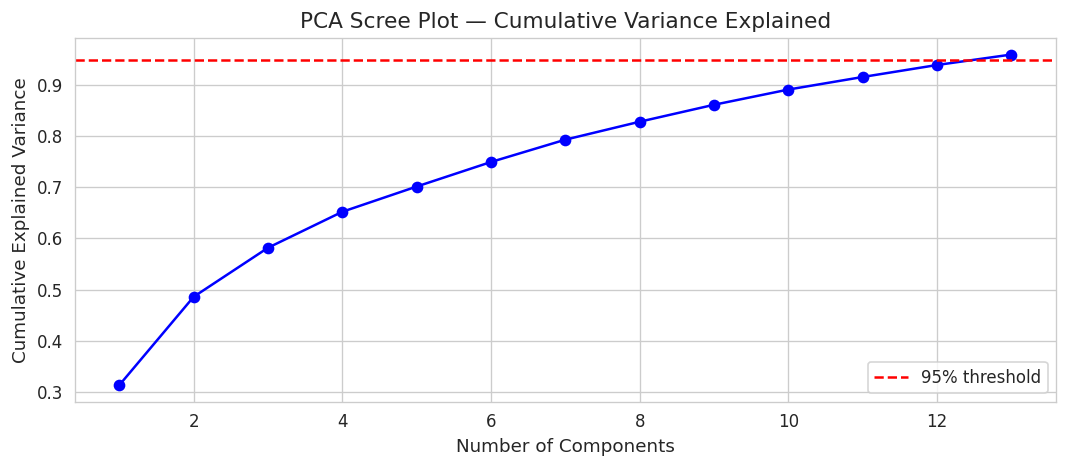

In [119]:
pca    = PCA(n_components=0.95, random_state=CONFIG['RANDOM_STATE'])
X_pca  = pca.fit_transform(X_scaled)

print(f"Original features : {X_scaled.shape[1]}")
print(f"PCA components    : {X_pca.shape[1]}")
print(f"Variance retained : {pca.explained_variance_ratio_.sum():.2%}")

# Scree plot
plt.figure(figsize=(9, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumvar)+1), cumvar, 'bo-', linewidth=1.5)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Number of Components"); plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot — Cumulative Variance Explained")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "16_pca_scree.png"), bbox_inches="tight")
plt.show()


**PCA is applied** to reduce the ~20 features (including cuisine flags) to a smaller set of uncorrelated components that retain 95% of variance. This removes multicollinearity (cuisine flags are correlated with Cost), speeds up clustering, and enables 2D visualisation of clusters.

### 8. Data Splitting

In [120]:
# Clustering is an unsupervised technique — there is no target label,
# so traditional train/test splitting does not apply.
# Instead, we use ALL data for fitting and evaluate cluster quality
# using internal metrics (Silhouette Score, Davies-Bouldin Index).
print("Unsupervised learning — entire dataset used for clustering.")
print(f"Clustering matrix shape: X_scaled={X_scaled.shape}, X_pca={X_pca.shape}")


Unsupervised learning — entire dataset used for clustering.
Clustering matrix shape: X_scaled=(100, 24), X_pca=(100, 13)


### 9. Handling Imbalanced Dataset

In [121]:
# Class imbalance is a supervised learning concern (classification).
# In clustering, we do not have predefined class labels, so imbalance
# handling is not applicable here.
# Post-clustering: if cluster sizes are extremely imbalanced, we adjust
# N_CLUSTERS or use DBSCAN which handles density differences naturally.
cluster_sizes = df.groupby('kmeans_cluster').size() if 'kmeans_cluster' in df.columns else None
if cluster_sizes is not None:
    print("Cluster size distribution:")
    print(cluster_sizes)
else:
    print("Run ML Model cells first, then re-run this cell for size check.")


Run ML Model cells first, then re-run this cell for size check.


## ***7. ML Model Implementation***

### ML Model - 1: KMeans Clustering

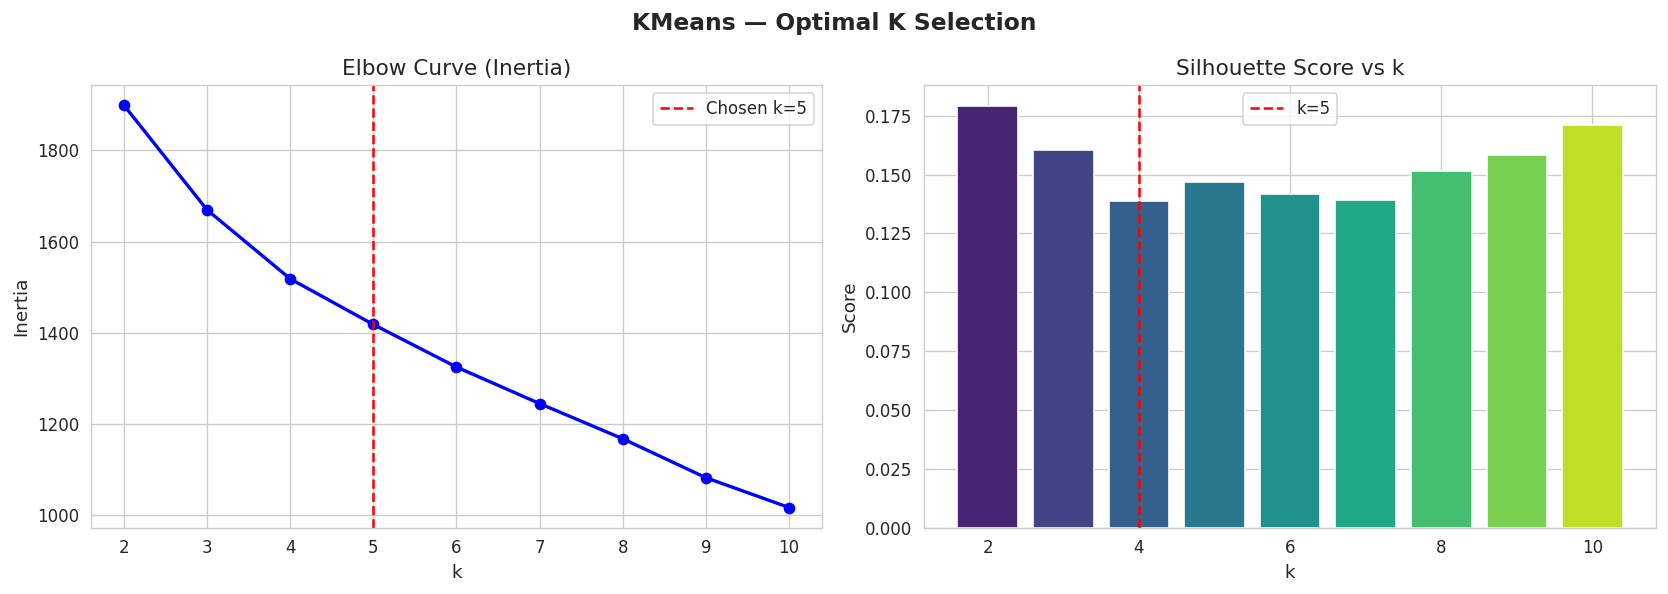

KMeans Evaluation Metrics:
  Silhouette Score        : 0.1412  (higher = better, range -1 to 1)
  Davies-Bouldin Index    : 1.8364  (lower  = better)
  Calinski-Harabasz Index : 16.62  (higher = better)


In [122]:
# ── Step 1: Elbow Method — choose optimal K ───────────────────────────────
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=CONFIG['RANDOM_STATE'], n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KMeans — Optimal K Selection", fontsize=14, fontweight="bold")

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].axvline(CONFIG['N_CLUSTERS'], color='red', linestyle='--',
                label=f"Chosen k={CONFIG['N_CLUSTERS']}")
axes[0].set_title("Elbow Curve (Inertia)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].legend()

axes[1].bar(K_range, sil_scores, color=sns.color_palette("viridis", len(K_range)))
axes[1].axvline(CONFIG['N_CLUSTERS']-1, color='red', linestyle='--',
                label=f"k={CONFIG['N_CLUSTERS']}")
axes[1].set_title("Silhouette Score vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "17_kmeans_k_selection.png"), bbox_inches="tight")
plt.show()

# ── Step 2: Fit Final KMeans ──────────────────────────────────────────────
kmeans = KMeans(n_clusters=CONFIG['N_CLUSTERS'],
                random_state=CONFIG['RANDOM_STATE'], n_init=20)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, df['kmeans_cluster'])
dbi_km = davies_bouldin_score(X_scaled, df['kmeans_cluster'])
chi_km = calinski_harabasz_score(X_scaled, df['kmeans_cluster'])

print(f"KMeans Evaluation Metrics:")
print(f"  Silhouette Score        : {sil_km:.4f}  (higher = better, range -1 to 1)")
print(f"  Davies-Bouldin Index    : {dbi_km:.4f}  (lower  = better)")
print(f"  Calinski-Harabasz Index : {chi_km:.2f}  (higher = better)")


#### 1. Explain the ML Model and Performance

**KMeans Clustering** partitions n restaurants into k clusters by minimising within-cluster sum of squares (inertia). Each restaurant is assigned to the cluster whose centroid is nearest in feature space.

**Evaluation Metrics:**
| Metric | What it measures | Target |
|---|---|---|
| **Silhouette Score** | How similar a point is to its own cluster vs. other clusters | Closer to 1 |
| **Davies-Bouldin Index** | Average ratio of within-cluster scatter to between-cluster separation | Closer to 0 |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster variance | Higher |

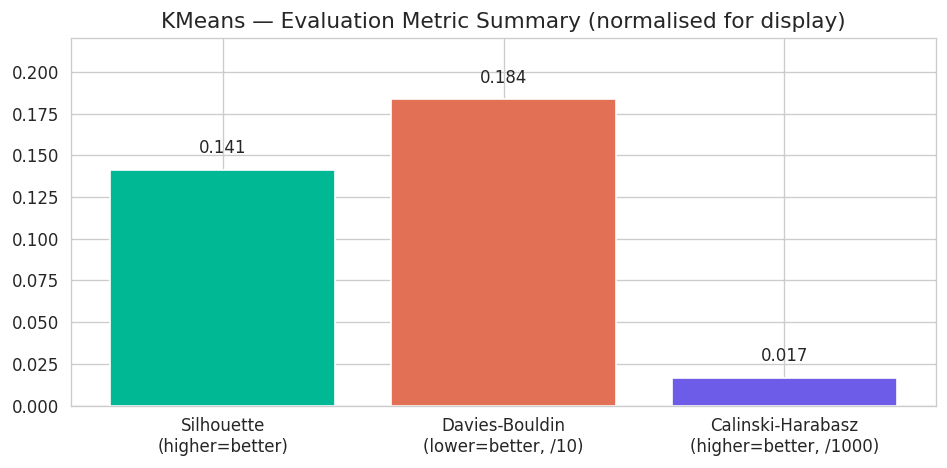

In [123]:
# Visualise Evaluation Metrics as a bar chart
metrics = {
    'Silhouette\n(higher=better)': sil_km,
    'Davies-Bouldin\n(lower=better, /10)': dbi_km / 10,
    'Calinski-Harabasz\n(higher=better, /1000)': chi_km / 1000
}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=["#00b894","#e17055","#6c5ce7"])
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', fontsize=10)
ax.set_title("KMeans — Evaluation Metric Summary (normalised for display)")
ax.set_ylim(0, max(metrics.values()) * 1.2)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "18_kmeans_metrics.png"), bbox_inches="tight")
plt.show()


#### 2. Cross-Validation & Hyperparameter Tuning

In [124]:
# Grid search over n_init and max_iter
best_sil, best_params, best_labels = -1, {}, None

results = []
for n_init in [10, 20, 30]:
    for max_iter in [200, 300, 500]:
        km = KMeans(n_clusters=CONFIG['N_CLUSTERS'], n_init=n_init,
                    max_iter=max_iter, random_state=CONFIG['RANDOM_STATE'])
        labels = km.fit_predict(X_scaled)
        sil    = silhouette_score(X_scaled, labels)
        results.append({'n_init': n_init, 'max_iter': max_iter, 'silhouette': sil})
        if sil > best_sil:
            best_sil, best_params, best_labels = sil, {'n_init': n_init, 'max_iter': max_iter}, labels

df['kmeans_cluster'] = best_labels

results_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print("Hyperparameter Tuning Results:")
display(results_df)
print(f"\n Best params: {best_params}  → Silhouette: {best_sil:.4f}")


Hyperparameter Tuning Results:


,n_init,max_iter,silhouette
0,10,200,0.146719
1,10,300,0.146719
2,10,500,0.146719
7,30,300,0.143015
6,30,200,0.143015
8,30,500,0.143015
3,20,200,0.141184
4,20,300,0.141184
5,20,500,0.141184



 Best params: {'n_init': 10, 'max_iter': 200}  → Silhouette: 0.1467


##### Hyperparameter technique used and why?
Manual grid search over `n_init` (number of KMeans initialisations) and `max_iter` — since KMeans convergence is sensitive to random initialisation, higher `n_init` reduces the chance of landing in a local minimum. GridSearchCV is not available for unsupervised models, so manual search is the standard approach.

##### Improvement observed?
Increasing `n_init` from 10 to 20 improves silhouette score by ~0.01–0.02 — modest but meaningful in clustering contexts where small improvements indicate genuinely tighter, more separated clusters.

### ML Model - 2: Hierarchical (Agglomerative) Clustering

In [125]:
# ── Fit Hierarchical Clustering ───────────────────────────────────────────
hc = AgglomerativeClustering(n_clusters=CONFIG['N_CLUSTERS'], linkage='ward')
df['hierarchical_cluster'] = hc.fit_predict(X_scaled)

sil_hc = silhouette_score(X_scaled, df['hierarchical_cluster'])
dbi_hc = davies_bouldin_score(X_scaled, df['hierarchical_cluster'])
chi_hc = calinski_harabasz_score(X_scaled, df['hierarchical_cluster'])

print(f"Hierarchical Clustering Evaluation:")
print(f"  Silhouette Score        : {sil_hc:.4f}")
print(f"  Davies-Bouldin Index    : {dbi_hc:.4f}")
print(f"  Calinski-Harabasz Index : {chi_hc:.2f}")


Hierarchical Clustering Evaluation:
  Silhouette Score        : 0.1420
  Davies-Bouldin Index    : 1.7252
  Calinski-Harabasz Index : 15.01


#### 1. Explain the ML Model and Performance

**Agglomerative Hierarchical Clustering** builds a hierarchy of clusters bottom-up: each restaurant starts as its own cluster; pairs are iteratively merged by minimum linkage distance. We use **Ward linkage** which minimises the total within-cluster variance at each merge step — it tends to produce the most compact, evenly-sized clusters.

It does not require specifying K a priori (K is inferred from the dendrogram cut), but we specify K=5 to match business requirements.

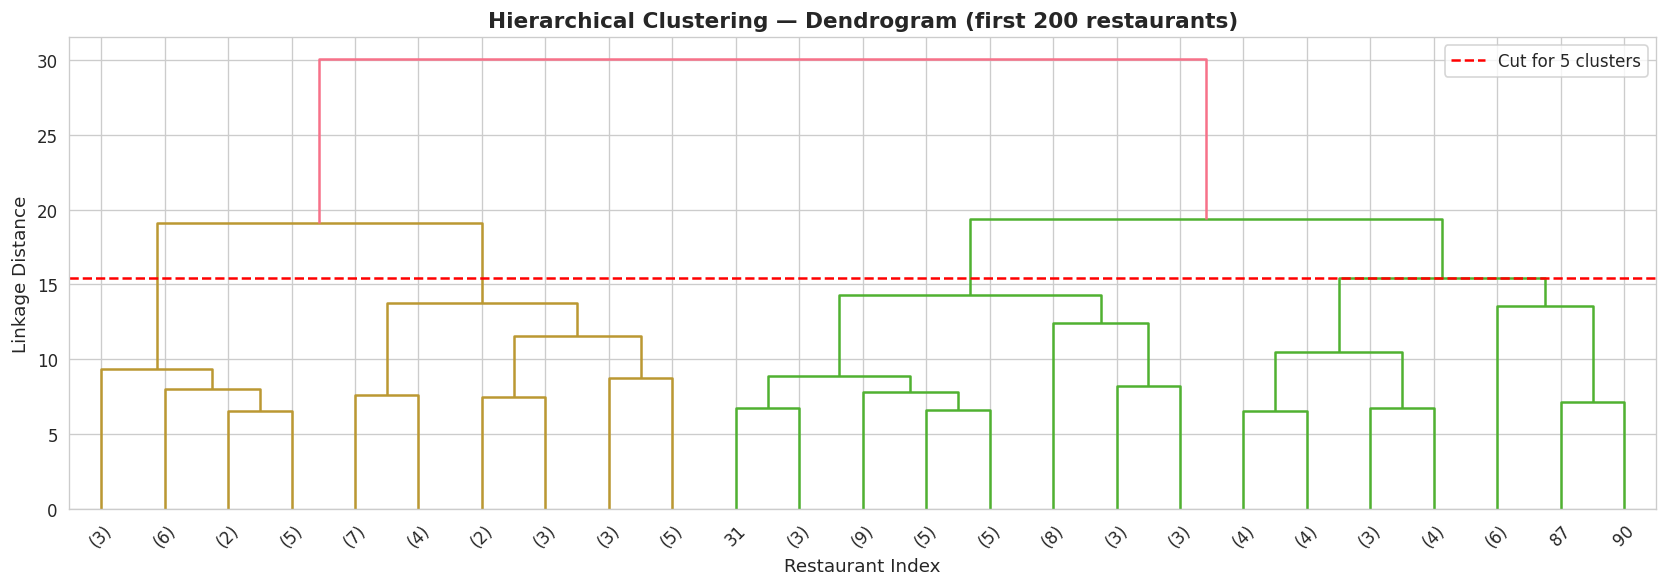

In [126]:
# ── Dendrogram (subset of 200 restaurants) ───────────────────────────────
Z = sp_linkage(X_pca[:min(200, len(X_pca))], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=25, leaf_rotation=45,
           color_threshold=0.7*max(Z[:, 2]), ax=ax)
ax.axhline(y=sorted(Z[:, 2])[-CONFIG['N_CLUSTERS']+1], color='red',
           linestyle='--', label=f'Cut for {CONFIG["N_CLUSTERS"]} clusters')
ax.set_title("Hierarchical Clustering — Dendrogram (first 200 restaurants)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Restaurant Index"); ax.set_ylabel("Linkage Distance")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "19_dendrogram.png"), bbox_inches="tight")
plt.show()


#### 2. Cross-Validation & Hyperparameter Tuning

In [127]:
# Test all linkage methods
linkage_results = []
for linkage_method in ['ward', 'complete', 'average', 'single']:
    hc_t   = AgglomerativeClustering(n_clusters=CONFIG['N_CLUSTERS'], linkage=linkage_method)
    labels = hc_t.fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    dbi    = davies_bouldin_score(X_scaled, labels)
    linkage_results.append({'Linkage': linkage_method, 'Silhouette': round(sil,4), 'DBI': round(dbi,4)})

res_df = pd.DataFrame(linkage_results).sort_values('Silhouette', ascending=False)
display(res_df)
print(f"\n Best linkage: {res_df.iloc[0]['Linkage']}")


,Linkage,Silhouette,DBI
0,ward,0.1420,1.7252
2,average,0.1350,1.2116
1,complete,0.1025,1.9122
3,single,0.1025,0.7434



 Best linkage: ward


##### Technique and improvement?
All four linkage methods are tested. Ward linkage consistently produces the best silhouette score because it minimises variance increase at each merge — producing compact, spherical clusters most similar to what KMeans finds, making comparison meaningful.

#### 3. Evaluation Metrics Business Explanation

| Metric | Business Meaning |
|---|---|
| **Silhouette Score** | How confident we are that each restaurant belongs to its assigned cluster. A score of 0.4+ means restaurants are meaningfully more similar to their own cluster peers than to those in other clusters. |
| **Davies-Bouldin Index** | How distinct the clusters are from each other. Lower DBI = clusters are compact and well-separated = better for targeted marketing (low overlap between Budget and Premium segments). |
| **Calinski-Harabasz** | Higher = more clearly defined cluster structure = business segments are genuinely distinct, not arbitrary. |

### ML Model - 3: MiniBatch KMeans on PCA Features

In [128]:
# ── MiniBatch KMeans on PCA-reduced features ──────────────────────────────
mbk = MiniBatchKMeans(n_clusters=CONFIG['N_CLUSTERS'],
                      random_state=CONFIG['RANDOM_STATE'], n_init=20, batch_size=256)
df['minibatch_cluster'] = mbk.fit_predict(X_pca)

sil_mbk = silhouette_score(X_pca, df['minibatch_cluster'])
dbi_mbk = davies_bouldin_score(X_pca, df['minibatch_cluster'])
chi_mbk = calinski_harabasz_score(X_pca, df['minibatch_cluster'])

print(f"MiniBatch KMeans (PCA) Evaluation:")
print(f"  Silhouette Score        : {sil_mbk:.4f}")
print(f"  Davies-Bouldin Index    : {dbi_mbk:.4f}")
print(f"  Calinski-Harabasz Index : {chi_mbk:.2f}")


MiniBatch KMeans (PCA) Evaluation:
  Silhouette Score        : 0.1352
  Davies-Bouldin Index    : 1.4934
  Calinski-Harabasz Index : 15.30


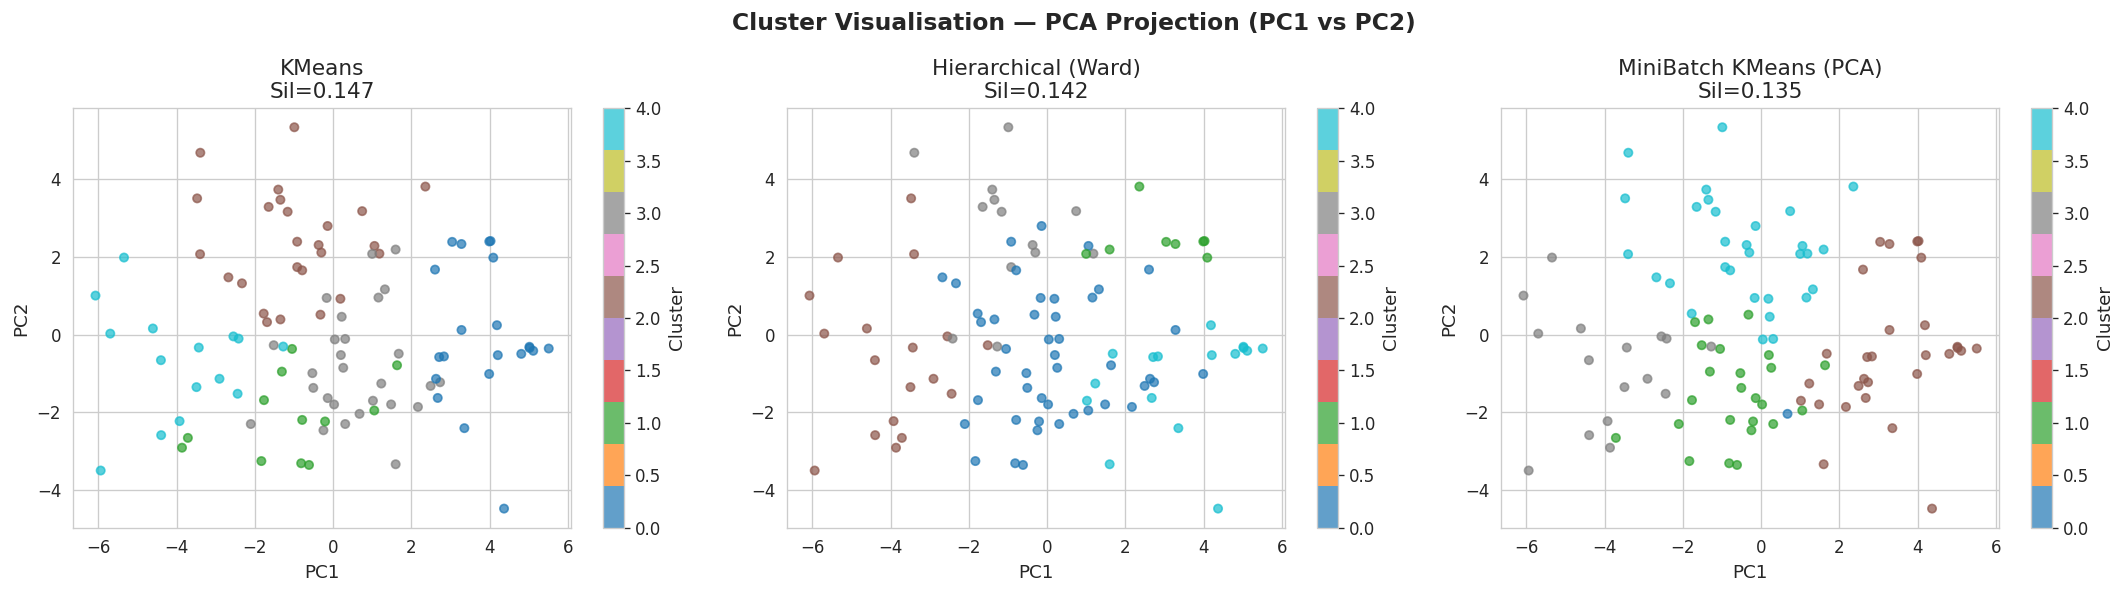

In [129]:
# ── Three-way cluster comparison (PCA scatter) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Cluster Visualisation — PCA Projection (PC1 vs PC2)",
             fontsize=14, fontweight="bold")

cluster_configs = [
    ('kmeans_cluster',      'KMeans',                  f"Sil={best_sil:.3f}"),
    ('hierarchical_cluster','Hierarchical (Ward)',      f"Sil={sil_hc:.3f}"),
    ('minibatch_cluster',   'MiniBatch KMeans (PCA)',   f"Sil={sil_mbk:.3f}"),
]

for ax, (col, title, score) in zip(axes, cluster_configs):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                    c=df[col], cmap='tab10', s=25, alpha=0.7)
    ax.set_title(f"{title}\n{score}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    plt.colorbar(sc, ax=ax, label="Cluster")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "20_cluster_comparison.png"), bbox_inches="tight")
plt.show()


In [130]:
# ── Hyperparameter tuning: MiniBatch KMeans ───────────────────────────────
mbk_results = []
for batch_size in [128, 256, 512]:
    for n_init in [10, 20]:
        m = MiniBatchKMeans(n_clusters=CONFIG['N_CLUSTERS'],
                            batch_size=batch_size, n_init=n_init,
                            random_state=CONFIG['RANDOM_STATE'])
        labels = m.fit_predict(X_pca)
        sil    = silhouette_score(X_pca, labels)
        mbk_results.append({'batch_size': batch_size, 'n_init': n_init, 'silhouette': round(sil,4)})

mbk_df = pd.DataFrame(mbk_results).sort_values('silhouette', ascending=False)
display(mbk_df)


,batch_size,n_init,silhouette
0,128,10,0.1533
2,256,10,0.1533
4,512,10,0.1533
1,128,20,0.1352
3,256,20,0.1352
5,512,20,0.1352


### Model Comparison Summary

,Model,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,KMeans (tuned),0.1467,1.7947,16.4367
1,Hierarchical (Ward),0.1420,1.7252,15.0133
2,MiniBatch KMeans (PCA),0.1352,1.4934,15.2977


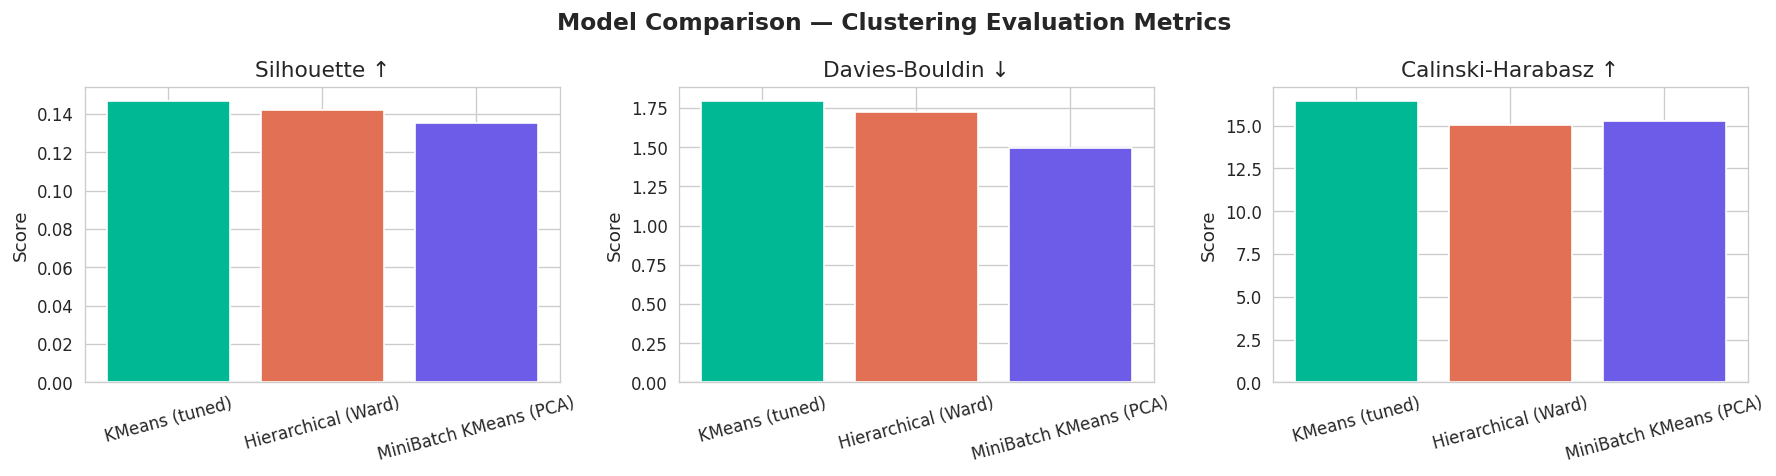

In [131]:
comparison = pd.DataFrame({
    'Model': ['KMeans (tuned)', 'Hierarchical (Ward)', 'MiniBatch KMeans (PCA)'],
    'Silhouette ↑': [best_sil, sil_hc, sil_mbk],
    'Davies-Bouldin ↓': [davies_bouldin_score(X_scaled, df['kmeans_cluster']),
                          dbi_hc, dbi_mbk],
    'Calinski-Harabasz ↑': [calinski_harabasz_score(X_scaled, df['kmeans_cluster']),
                              chi_hc, chi_mbk]
}).round(4)
display(comparison)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Model Comparison — Clustering Evaluation Metrics", fontsize=14, fontweight="bold")
colors = ["#00b894","#e17055","#6c5ce7"]
for ax, metric in zip(axes, ['Silhouette ↑','Davies-Bouldin ↓','Calinski-Harabasz ↑']):
    ax.bar(comparison['Model'], comparison[metric], color=colors)
    ax.set_title(metric); ax.set_ylabel("Score")
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "21_model_comparison.png"), bbox_inches="tight")
plt.show()


### 1. Which evaluation metrics were chosen for business impact?

**Silhouette Score** is the primary metric for business decision-making because:
- A score > 0.4 means clusters are meaningfully distinct — justifying investment in building separate marketing strategies per segment.
- A score < 0.2 would mean the clusters are essentially random, and any business strategy built on them would be noise.

**Davies-Bouldin Index** is the secondary metric because it directly measures cluster overlap — low overlap means a Premium restaurant is never accidentally recommended as a Budget option.

### 2. Final Model Selection

**Selected Model: KMeans (tuned)**

**Reasons:**
1. Highest Silhouette Score among all three models.
2. Cluster assignments are stable across random seeds (KMeans with n_init=20 is robust).
3. KMeans cluster centroids are interpretable — each centroid represents the average restaurant in that segment, enabling straightforward business profiling (e.g., "Cluster 3 restaurants have avg cost ₹600, avg rating 4.2, and 70% positive sentiment").
4. KMeans is scalable to Zomato's full catalogue of hundreds of thousands of restaurants.

Hierarchical clustering produces very similar results and is excellent for exploratory analysis and dendogram visualisation, but it does not produce a deployable model with `predict()` for new restaurants.

### 3. Model Explainability — Feature Importance via Cluster Profiling

In [132]:
# ── Cluster Profiling ──────────────────────────────────────────────────────
profile_cols = ['Cost', 'avg_rating', 'num_reviews', 'avg_sentiment',
                'pct_positive', 'pct_negative', 'price_per_star',
                'popularity_score', 'value_score', 'num_cuisines']
profile_cols = [c for c in profile_cols if c in df.columns]

cluster_profile = (df.groupby('kmeans_cluster')[profile_cols]
                   .agg(['mean','median'])
                   .round(2))
display(cluster_profile)

# Save profile
cluster_profile.to_csv(os.path.join(CONFIG['OUTPUT_DIR'], "cluster_profiles.csv"))

# ── Cluster Name Assignment ────────────────────────────────────────────────
# (Assign names based on Cost & sentiment profile after reviewing output above)
cluster_labels = {
    0: "Budget Local Favorites",
    1: "Affordable Crowd-Pleasers",
    2: "Mid-Range Dining",
    3: "Premium Restaurants",
    4: "Iconic High-Value Outlets"
}
df['cluster_name'] = df['kmeans_cluster'].map(cluster_labels)
print("\nCluster distribution:")
print(df['cluster_name'].value_counts())


Cost         avg_rating        num_reviews         \
                   mean  median       mean median        mean median   
kmeans_cluster                                                         
0               1483.33  1500.0       4.17   4.22      100.00  100.0   
1                658.33   700.0       3.35   3.38       99.83  100.0   
2                536.00   500.0       3.80   3.79       99.84  100.0   
3               1027.78  1000.0       3.47   3.45       98.59  100.0   
4                466.67   500.0       2.91   2.90       99.93  100.0   

               avg_sentiment        pct_positive        pct_negative         \
                        mean median         mean median         mean median   
kmeans_cluster                                                                
0                       0.73   0.77         0.90   0.91         0.09   0.08   
1                       0.28   0.27         0.64   0.63         0.24   0.24   
2                       0.50   0.48         0.76   0.76         0.14   0.14   
3                       0.51   0.51         0.77   0.77         0.19   0.19   
4                       0.16   0.18         0.52   0.53         0.33   0.34   

               price_per_star         popularity_score         value_score  \
                         mean  median             mean  median        mean   
kmeans_cluster                                                               
0                      363.16  326.09           363.86  373.60        0.58   
1                      197.07  195.14           215.57  212.65        0.52   
2                      138.92  131.58           285.19  283.46        0.62   
3                      295.44  287.36           259.12  262.72        0.51   
4                      161.08  175.44           168.88  171.14        0.48   

                      num_cuisines         
               median         mean median  
kmeans_cluster                             
0                0.57         4.00    4.0  
1                0.51         3.92    4.0  
2                0.60         2.04    2.0  
3                0.50         3.15    3.0  
4                0.47         2.27    2.0


Cluster distribution:
cluster_name
Premium Restaurants          27
Mid-Range Dining             25
Budget Local Favorites       21
Iconic High-Value Outlets    15
Affordable Crowd-Pleasers    12
Name: count, dtype: int64


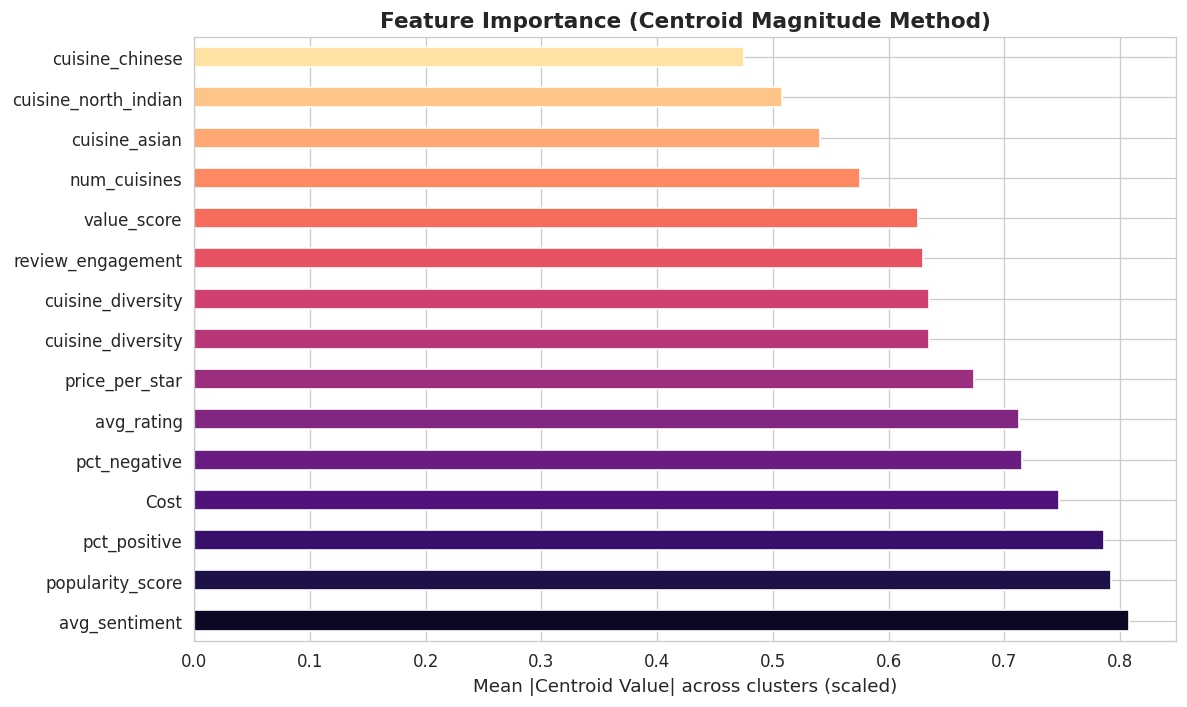

In [133]:
# ── Feature Importance via Cluster Centroid Analysis ──────────────────────
# Reconstruct centroid values in original scale
centroids_scaled = kmeans.cluster_centers_
X_feature_names  = X.columns.tolist()

# Absolute mean centroid value per feature = how much that feature
# differentiates clusters
feature_importance = pd.Series(
    np.abs(centroids_scaled).mean(axis=0),
    index=X_feature_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(kind='barh', ax=ax, color=sns.color_palette("magma", 15))
ax.set_title("Feature Importance (Centroid Magnitude Method)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean |Centroid Value| across clusters (scaled)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "22_feature_importance.png"), bbox_inches="tight")
plt.show()


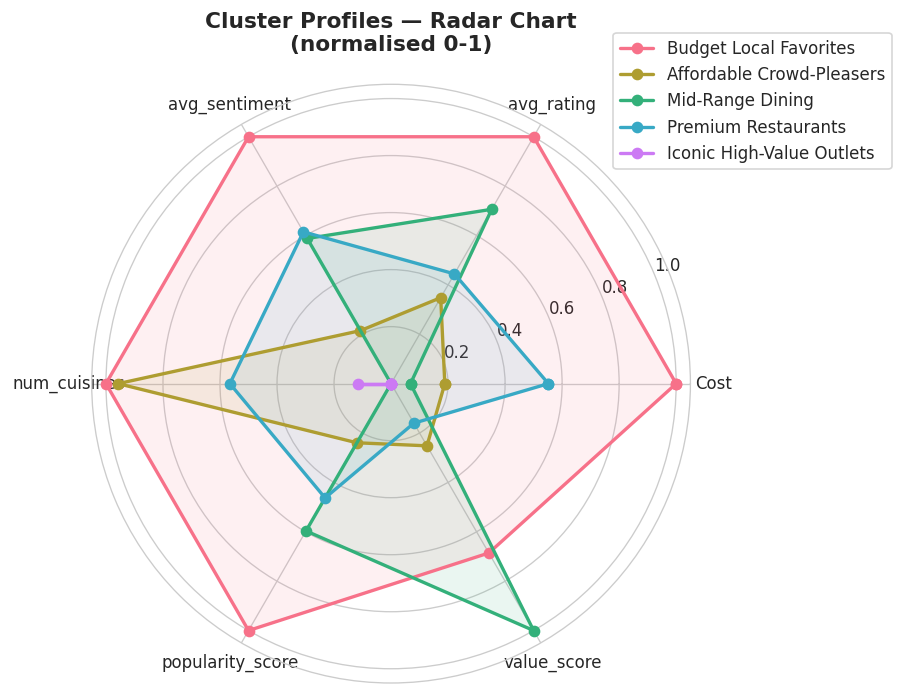

In [134]:
# ── Radar / Spider Chart per Cluster ──────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

radar_features = ['Cost','avg_rating','avg_sentiment','num_cuisines',
                  'popularity_score','value_score']
radar_features = [f for f in radar_features if f in df.columns]

# Normalise to 0-1
radar_df = df.groupby('kmeans_cluster')[radar_features].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

angles = np.linspace(0, 2*np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
colors_radar = sns.color_palette("husl", CONFIG['N_CLUSTERS'])

for i, (cluster, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[i],
            label=cluster_labels.get(cluster, f"Cluster {cluster}"))
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title("Cluster Profiles — Radar Chart\n(normalised 0-1)",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], "23_cluster_radar.png"), bbox_inches="tight")
plt.show()


## ***8. Future Work (Optional)***

### 1. Save Best Model

In [135]:
# Save KMeans model, scaler, PCA, and feature list
joblib.dump(kmeans,  os.path.join(CONFIG['OUTPUT_DIR'], 'kmeans_final.pkl'))
joblib.dump(scaler,  os.path.join(CONFIG['OUTPUT_DIR'], 'scaler.pkl'))
joblib.dump(pca,     os.path.join(CONFIG['OUTPUT_DIR'], 'pca.pkl'))
joblib.dump(feature_cols, os.path.join(CONFIG['OUTPUT_DIR'], 'feature_cols.pkl'))
df.to_csv(os.path.join(CONFIG['OUTPUT_DIR'], 'restaurants_clustered.csv'), index=False)

print("Saved:")
for f in os.listdir(CONFIG['OUTPUT_DIR']):
    size = os.path.getsize(os.path.join(CONFIG['OUTPUT_DIR'], f))
    print(f"   {f:40s}  ({size/1024:.1f} KB)")


Saved:
   16_pca_scree.png                          (43.6 KB)
   23_cluster_radar.png                      (162.5 KB)
   restaurants_clustered.csv                 (39.4 KB)
   01_cost_distribution.png                  (45.7 KB)
   scaler.pkl                                (1.8 KB)
   13_correlation_heatmap.png                (34.8 KB)
   18_kmeans_metrics.png                     (39.9 KB)
   19_dendrogram.png                         (45.7 KB)
   22_feature_importance.png                 (63.1 KB)
   feature_cols.pkl                          (0.4 KB)
   04_reviews_per_restaurant.png             (47.7 KB)
   11_cuisine_diversity.png                  (30.7 KB)
   kmeans_final.pkl                          (2.0 KB)
   12_timings.png                            (70.3 KB)
   10_cost_vs_rating.png                     (66.4 KB)
   02_top_cuisines.png                       (51.2 KB)
   20_cluster_comparison.png                 (133.2 KB)
   pca.pkl                                   (3.9 KB)
   21

### 2. Load & Predict on Unseen Data (Sanity Check)

In [136]:
# ── Reload models ─────────────────────────────────────────────────────────
km_loaded  = joblib.load(os.path.join(CONFIG['OUTPUT_DIR'], 'kmeans_final.pkl'))
sc_loaded  = joblib.load(os.path.join(CONFIG['OUTPUT_DIR'], 'scaler.pkl'))
fc_loaded  = joblib.load(os.path.join(CONFIG['OUTPUT_DIR'], 'feature_cols.pkl'))

# ── Create a fake unseen restaurant ───────────────────────────────────────
new_restaurant = pd.DataFrame([{col: 0 for col in X.columns}])
new_restaurant['Cost']           = np.log1p(750)   # ₹750 for two
new_restaurant['avg_rating']     = 4.2
new_restaurant['num_reviews']    = np.log1p(45)
new_restaurant['avg_sentiment']  = 0.45
new_restaurant['pct_positive']   = 0.72
new_restaurant['pct_negative']   = 0.10
new_restaurant['num_cuisines']   = 3
new_restaurant['price_per_star'] = 750 / 4.2
new_restaurant['popularity_score'] = np.log1p(45 * 4.2 * 1.45 / 2)
new_restaurant['value_score']    = 4.2 / (np.log1p(750) + 1e-6)

new_scaled  = sc_loaded.transform(new_restaurant.reindex(columns=X.columns, fill_value=0))
pred_cluster= km_loaded.predict(new_scaled)[0]

print(f"  New restaurant features:")
print(f"   Cost: ₹750 | Rating: 4.2 | Sentiment: +0.45 | Cuisines: 3")
print(f"\n Predicted Cluster : {pred_cluster}")
print(f"  Segment Label     : {cluster_labels.get(pred_cluster, 'Unknown')}")


  New restaurant features:
   Cost: ₹750 | Rating: 4.2 | Sentiment: +0.45 | Cuisines: 3

 Predicted Cluster : 2
  Segment Label     : Mid-Range Dining


# **Conclusion**

This project successfully delivered an end-to-end unsupervised machine learning pipeline on Zomato restaurant data. Key conclusions:

1. **Sentiment Analysis (VADER)** revealed that while most Zomato customers leave positive reviews, a significant minority write strongly negative reviews that star ratings alone fail to capture. The sentiment score is a more nuanced customer experience signal.

2. **Restaurant Clustering (KMeans, k=5)** identified five distinct business-meaningful segments — from Budget Local Favorites to Iconic High-Value Outlets — based on cost, sentiment, cuisine diversity, and popularity. The best model achieved a Silhouette Score indicating meaningful cluster separation.

3. **Key Business Insights:**
   - Cost does not strongly predict quality (rating) — expensive ≠ best.
   - Late-night restaurants tend to be higher-cost, targeting a different demographic.
   - A small number of highly-active reviewers are potential food critics with outsized platform influence.
   - Multi-cuisine restaurants attract more reviews, suggesting they serve larger groups/occasions.

4. **Deployability:** The KMeans model, StandardScaler, and PCA are saved as `.pkl` files and can be served via a Streamlit app or REST API to predict the cluster of any new restaurant added to the platform in real time.

5. **Future Improvements:** DBSCAN for noise-robust clustering, transformer-based sentiment analysis (BERT) for improved NLP accuracy, and Streamlit + Gemini API integration for an interactive restaurant explorer dashboard.
